In [3]:
%load_ext autoreload
%autoreload 2
import sys

ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")


import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection, multipletests

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [4]:
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'
fm.fontManager.addfont(font_path)  # Only if you're adding a new font file
fm._load_fontmanager(try_read_cache=False)

# HumanCT IQ Phenotype


In [152]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.TPM.0.1.Filt.Spec.clip.lowexp.cut1e4.csv", index_col=0)
HumanCT_Z2_HCT.columns = HumanCT_Z2_HCT.columns.astype(int)

In [153]:
Mut_n_IQ = pd.read_csv("../dat/ASD_IQ_Mut.csv")
Mut_n_IQ.columns.values

array(['IID', 'Sex', 'Pheno', 'VarID', 'GeneID', 'HGNC', 'GeneEff',
       'REVEL', 'ExACpLI', 'Entrez', 'IQ'], dtype=object)

In [154]:
Spark_Denovo = pd.read_excel("../dat/41588_2022_1148_MOESM4_ESM.xlsx",
                           skiprows=2, sheet_name="Table S7")
Spark_Denovo = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]!="."]
Spark_Denovo_ExomeWide = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]<=1.3e-6]
Spark_Denovo_ExomeWide.shape

(61, 56)

In [211]:
top_Genes = Spark_Denovo.head(61)["HGNC"].values
Mut_n_IQ_conf = Mut_n_IQ[Mut_n_IQ["HGNC"].isin(top_Genes)]
Mut_n_IQ_conf.to_csv("/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Pheno_Bias_vs_IQ/Mut_n_IQ_conf.csv", index=False)
Mut_n_IQ_conf.shape

(221, 11)

In [213]:
#### Gene Level
Genes = list(set(Mut_n_IQ_conf["Entrez"].values))
data = []
for g in Genes:
    tmp_df = Mut_n_IQ_conf[Mut_n_IQ_conf["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data.append(row)
columns = ["Entrez", "IQ"]
Avg_Gene_IQ_DF = pd.DataFrame(data=data, columns=columns)
Avg_Gene_IQ_DF.to_csv("/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Pheno_Bias_vs_IQ/Mut_n_IQ_conf.GeneL.csv")

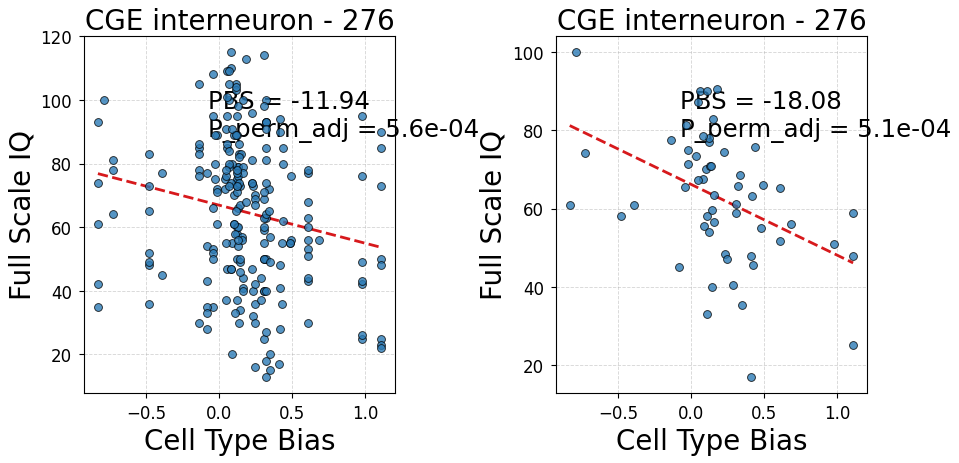

In [103]:
STR = 276
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax2)
plt.tight_layout()
plt.show()

In [104]:
STR = 276
biases, IQs = BiasVsPheno(Avg_Gene_IQ_DF, HumanCT_Z2_HCT , STR, 'XX')
# save biases, IQs to file
np.savetxt("biases.txt", biases)
np.savetxt("IQs.txt", IQs)

# load biases, IQs from file 
biases = np.loadtxt("biases.txt")
IQs = np.loadtxt("IQs.txt")


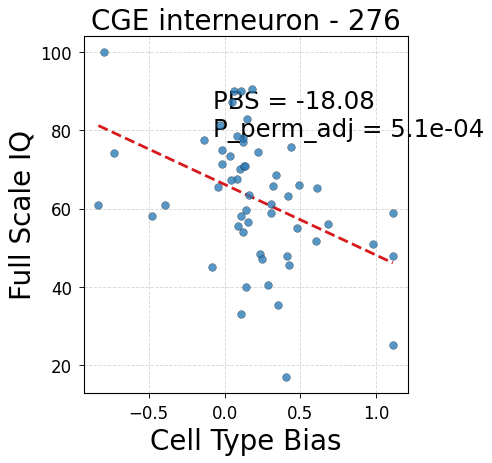

In [105]:
STR = 276
plt.style.use('seaborn-v0_8-paper')
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 6))
#Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HCT_Z2_MAT_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1)
plt.tight_layout()
plt.show()

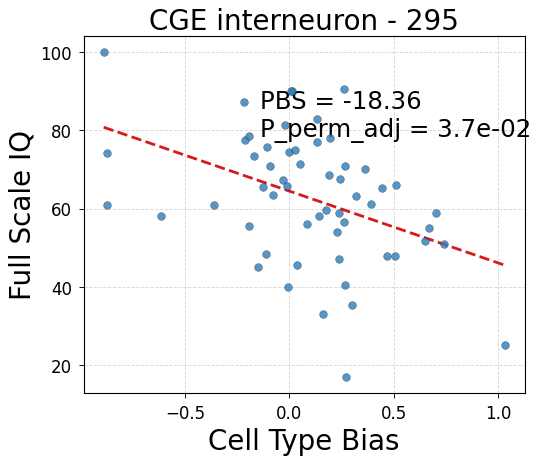

In [106]:
STR = 295
plt.style.use('seaborn-v0_8-paper')
fig, (ax1) = plt.subplots(1, 1, figsize=(7, 6))
#Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HCT_Z2_MAT_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1, Pval=0.037)
plt.tight_layout()
plt.show()

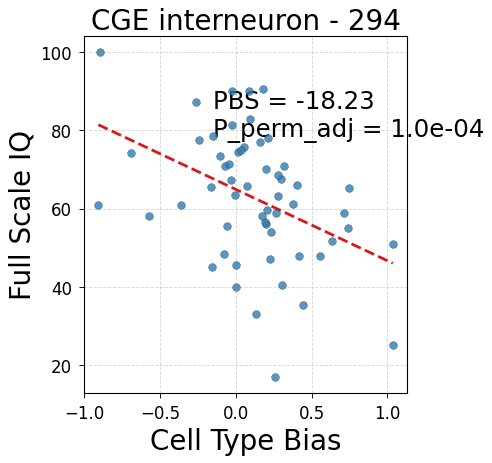

In [107]:
STR = 294
plt.style.use('seaborn-v0_8-paper')
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 6))
#Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1, Pval=0.0001)
plt.tight_layout()
plt.show()

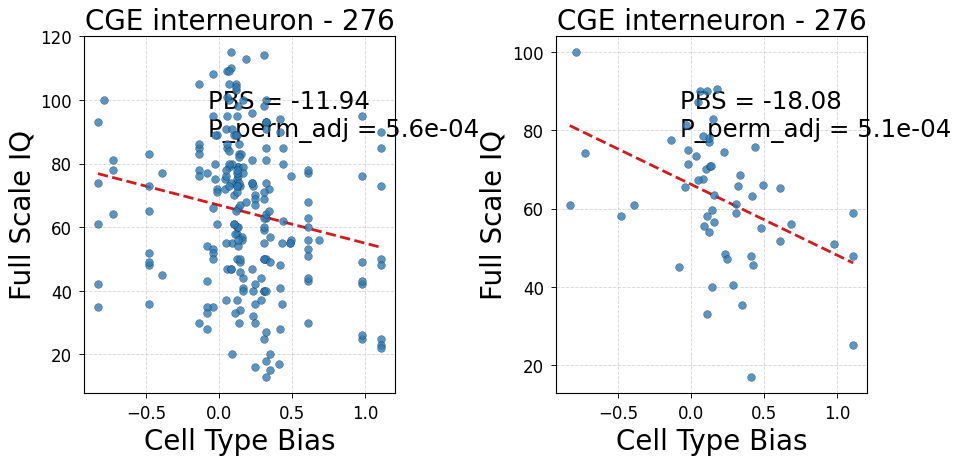

In [108]:
STR = 276
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax2)
plt.tight_layout()
plt.show()

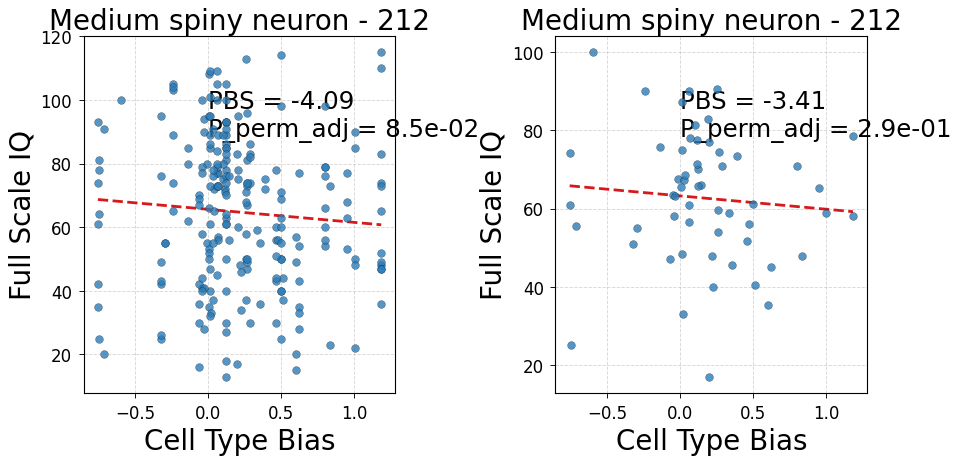

In [109]:
STR = 212
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax2)
plt.tight_layout()
plt.show()

In [110]:
Neuron_idx = Anno[Anno["Supercluster"].isin(Neurons)].index.values

In [111]:
def linear_fit(biases, IQs, alpha=0.05):
    model = sm.OLS(IQs, sm.add_constant(biases))
    results = model.fit()
    
    intercept = results.params[0]
    beta = results.params[1]
    # get CI of beta
    ci = results.conf_int(alpha=alpha)

    ci_low = ci[1][0]
    ci_high = ci[1][1]     
    r_value = results.rsquared
    p_value = results.pvalues[1]
    std_err = results.bse[1]
    rho, p_rho = spearmanr(biases, IQs)
    r, p_r = pearsonr(biases, IQs)
    
    return intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r

def Make_HumanCT_DF(Mut_n_IQ_conf, HCT_Z2_MAT_HCT, output_file, alpha=0.05):
    names, supercluster, spearmanr, spearmanp, pearsonr, pearsonp, beta_values, beta_ci_low, beta_ci_high, intercept_values, r_value_values, p_value_values, std_err_values = [],[],[],[],[],[],[],[],[],[],[],[],[]
    for Idx in HCT_Z2_MAT_HCT.columns.values:
        biases, IQs = BiasVsPheno(Mut_n_IQ_conf, HCT_Z2_MAT_HCT , Idx, 'xx')
        intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r = linear_fit(biases, IQs, alpha=0.05)
        
        names.append("{}".format(Idx))
        supercluster.append(Anno.loc[Idx, "Supercluster"])
        spearmanr.append(rho)
        spearmanp.append(p_rho)
        pearsonr.append(r)
        pearsonp.append(p_r)
        beta_values.append(beta)
        beta_ci_low.append(ci_low)
        beta_ci_high.append(ci_high)
        intercept_values.append(intercept)
        r_value_values.append(r_value)
        p_value_values.append(p_value)
        std_err_values.append(std_err)

    str_res_df = pd.DataFrame(data={"CT":names, "Supercluster":supercluster, "SpearmanR":spearmanr, "SpearmanP":spearmanp, 
                                            "PearsonR":pearsonr, "PearsonP":pearsonp, "beta":beta_values, "CI_low":beta_ci_low, "CI_high":beta_ci_high, "intercept":intercept_values, "r_value":r_value_values, 
                                            "p_value":p_value_values, "std_err":std_err_values})
    str_res_df = str_res_df.sort_values("SpearmanR")
    #str_res_df = ADJ_P(str_res_df)
    str_res_df.to_csv(output_file)
    return str_res_df

In [112]:
HumanCT_res_df_MutL = Make_HumanCT_DF(Mut_n_IQ_conf, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.spec.MutL.csv")
HumanCT_res_df_GeneL = Make_HumanCT_DF(Avg_Gene_IQ_DF, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.spec.GeneL.csv")


In [163]:
Mut_n_IQ_conf

,IID,Sex,Pheno,VarID,GeneID,HGNC,GeneEff,REVEL,ExACpLI,Entrez,IQ
8,200675470@1082034721,Female,Affected,12:56566368:C:A,ENSG00000139613,SMARCC2,splice_donor,.,0.999999989,6601,55.0
11,08C77167,Male,Affected,17:60650729:G:GT,ENSG00000146872,TLK2,splice_donor,.,0.999999806,11011,89.0
14,08C74145,Male,Affected,14:21865980:A:T,ENSG00000100888,CHD8,splice_donor,.,1,57680,100.0
24,AU065A,Male,Affected,10:89711874:G:A,ENSG00000171862,PTEN,splice_acceptor,.,0.975506866,5728,35.0
27,009-07-107601,Male,Affected,17:29670026:G:C,ENSG00000196712,NF1,splice_acceptor,.,0.999999846,4763,47.0
...,...,...,...,...,...,...,...,...,...,...,...
1853,SP0147668,Female,Affected,3:71026803:T:A,ENSG00000114861,FOXP1,missense,0.877,0.999750735055125,27086,73.0
1854,SP0119666,Male,Affected,16:89349326:C:CT,ENSG00000167522,ANKRD11,frameshift,.,0.999999821632236,29123,84.0
1855,SP0160988,Female,Affected,6:157100436:CGGCGGCGGGGGCGGCGGCG:C,ENSG00000049618,ARID1B,frameshift,.,0.999949930200412,57492,51.0
1856,SP0155495,Female,Affected,9:77277414:T:C,ENSG00000198963,RORB,missense,0.959,0.998551700707594,6096,78.0


In [113]:
HumanCT_res_df_GeneL.sort_values("SpearmanR").head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330
266,266,LAMP5-LHX6 and Chandelier,-0.470757,0.000251,-0.353220,0.007578,-14.405018,-24.814352,-3.995684,64.630648,0.124764,0.007578,5.192000
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758
239,239,MGE interneuron,-0.424077,0.001125,-0.405046,0.001957,-16.983547,-27.442845,-6.524249,65.529179,0.164062,0.001957,5.216921
268,268,LAMP5-LHX6 and Chandelier,-0.420761,0.001242,-0.387999,0.003129,-16.778903,-27.653043,-5.904763,65.083869,0.150543,0.003129,5.423838
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708
265,265,LAMP5-LHX6 and Chandelier,-0.404936,0.001964,-0.346602,0.008873,-14.334666,-24.918809,-3.750523,64.130645,0.120133,0.008873,5.279192
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977
269,269,LAMP5-LHX6 and Chandelier,-0.389574,0.003000,-0.381814,0.003688,-16.304049,-27.071661,-5.536437,65.611086,0.145782,0.003688,5.370704


In [114]:
HumanCT_res_df_GeneL.sort_values("beta").head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
236,236,MGE interneuron,-0.375602,0.004336,-0.391401,0.002855,-19.434111,-31.900093,-6.968130,64.516750,0.153194,0.002855,6.217822
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727
240,240,MGE interneuron,-0.378241,0.004050,-0.383223,0.003554,-17.758245,-29.435741,-6.080749,65.525407,0.146860,0.003554,5.824538
286,286,CGE interneuron,-0.306867,0.021426,-0.360944,0.006277,-17.734122,-30.235279,-5.232965,65.051352,0.130281,0.006277,6.235366
257,257,MGE interneuron,-0.225006,0.095461,-0.332159,0.012383,-17.722334,-31.452641,-3.992027,63.751094,0.110330,0.012383,6.848446


In [115]:
HumanCT_res_df_GeneL.sort_values("p_value").head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727
239,239,MGE interneuron,-0.424077,0.001125,-0.405046,0.001957,-16.983547,-27.442845,-6.524249,65.529179,0.164062,0.001957,5.216921
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708
236,236,MGE interneuron,-0.375602,0.004336,-0.391401,0.002855,-19.434111,-31.900093,-6.968130,64.516750,0.153194,0.002855,6.217822
268,268,LAMP5-LHX6 and Chandelier,-0.420761,0.001242,-0.387999,0.003129,-16.778903,-27.653043,-5.904763,65.083869,0.150543,0.003129,5.423838
240,240,MGE interneuron,-0.378241,0.004050,-0.383223,0.003554,-17.758245,-29.435741,-6.080749,65.525407,0.146860,0.003554,5.824538


In [117]:
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="CGE interneuron"]["beta"]))
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="LAMP5-LHX6 and Chandelier"]["beta"]))
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="MGE interneuron"]["beta"]))

-15.419037348555849
-15.374304370403467
-15.4281167460514


In [118]:
HumanCT_res_df_GeneL.head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330
266,266,LAMP5-LHX6 and Chandelier,-0.470757,0.000251,-0.353220,0.007578,-14.405018,-24.814352,-3.995684,64.630648,0.124764,0.007578,5.192000
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758
239,239,MGE interneuron,-0.424077,0.001125,-0.405046,0.001957,-16.983547,-27.442845,-6.524249,65.529179,0.164062,0.001957,5.216921
268,268,LAMP5-LHX6 and Chandelier,-0.420761,0.001242,-0.387999,0.003129,-16.778903,-27.653043,-5.904763,65.083869,0.150543,0.003129,5.423838
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708
265,265,LAMP5-LHX6 and Chandelier,-0.404936,0.001964,-0.346602,0.008873,-14.334666,-24.918809,-3.750523,64.130645,0.120133,0.008873,5.279192
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977
269,269,LAMP5-LHX6 and Chandelier,-0.389574,0.003000,-0.381814,0.003688,-16.304049,-27.071661,-5.536437,65.611086,0.145782,0.003688,5.370704


/tmp/ipykernel_37119/3403990755.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


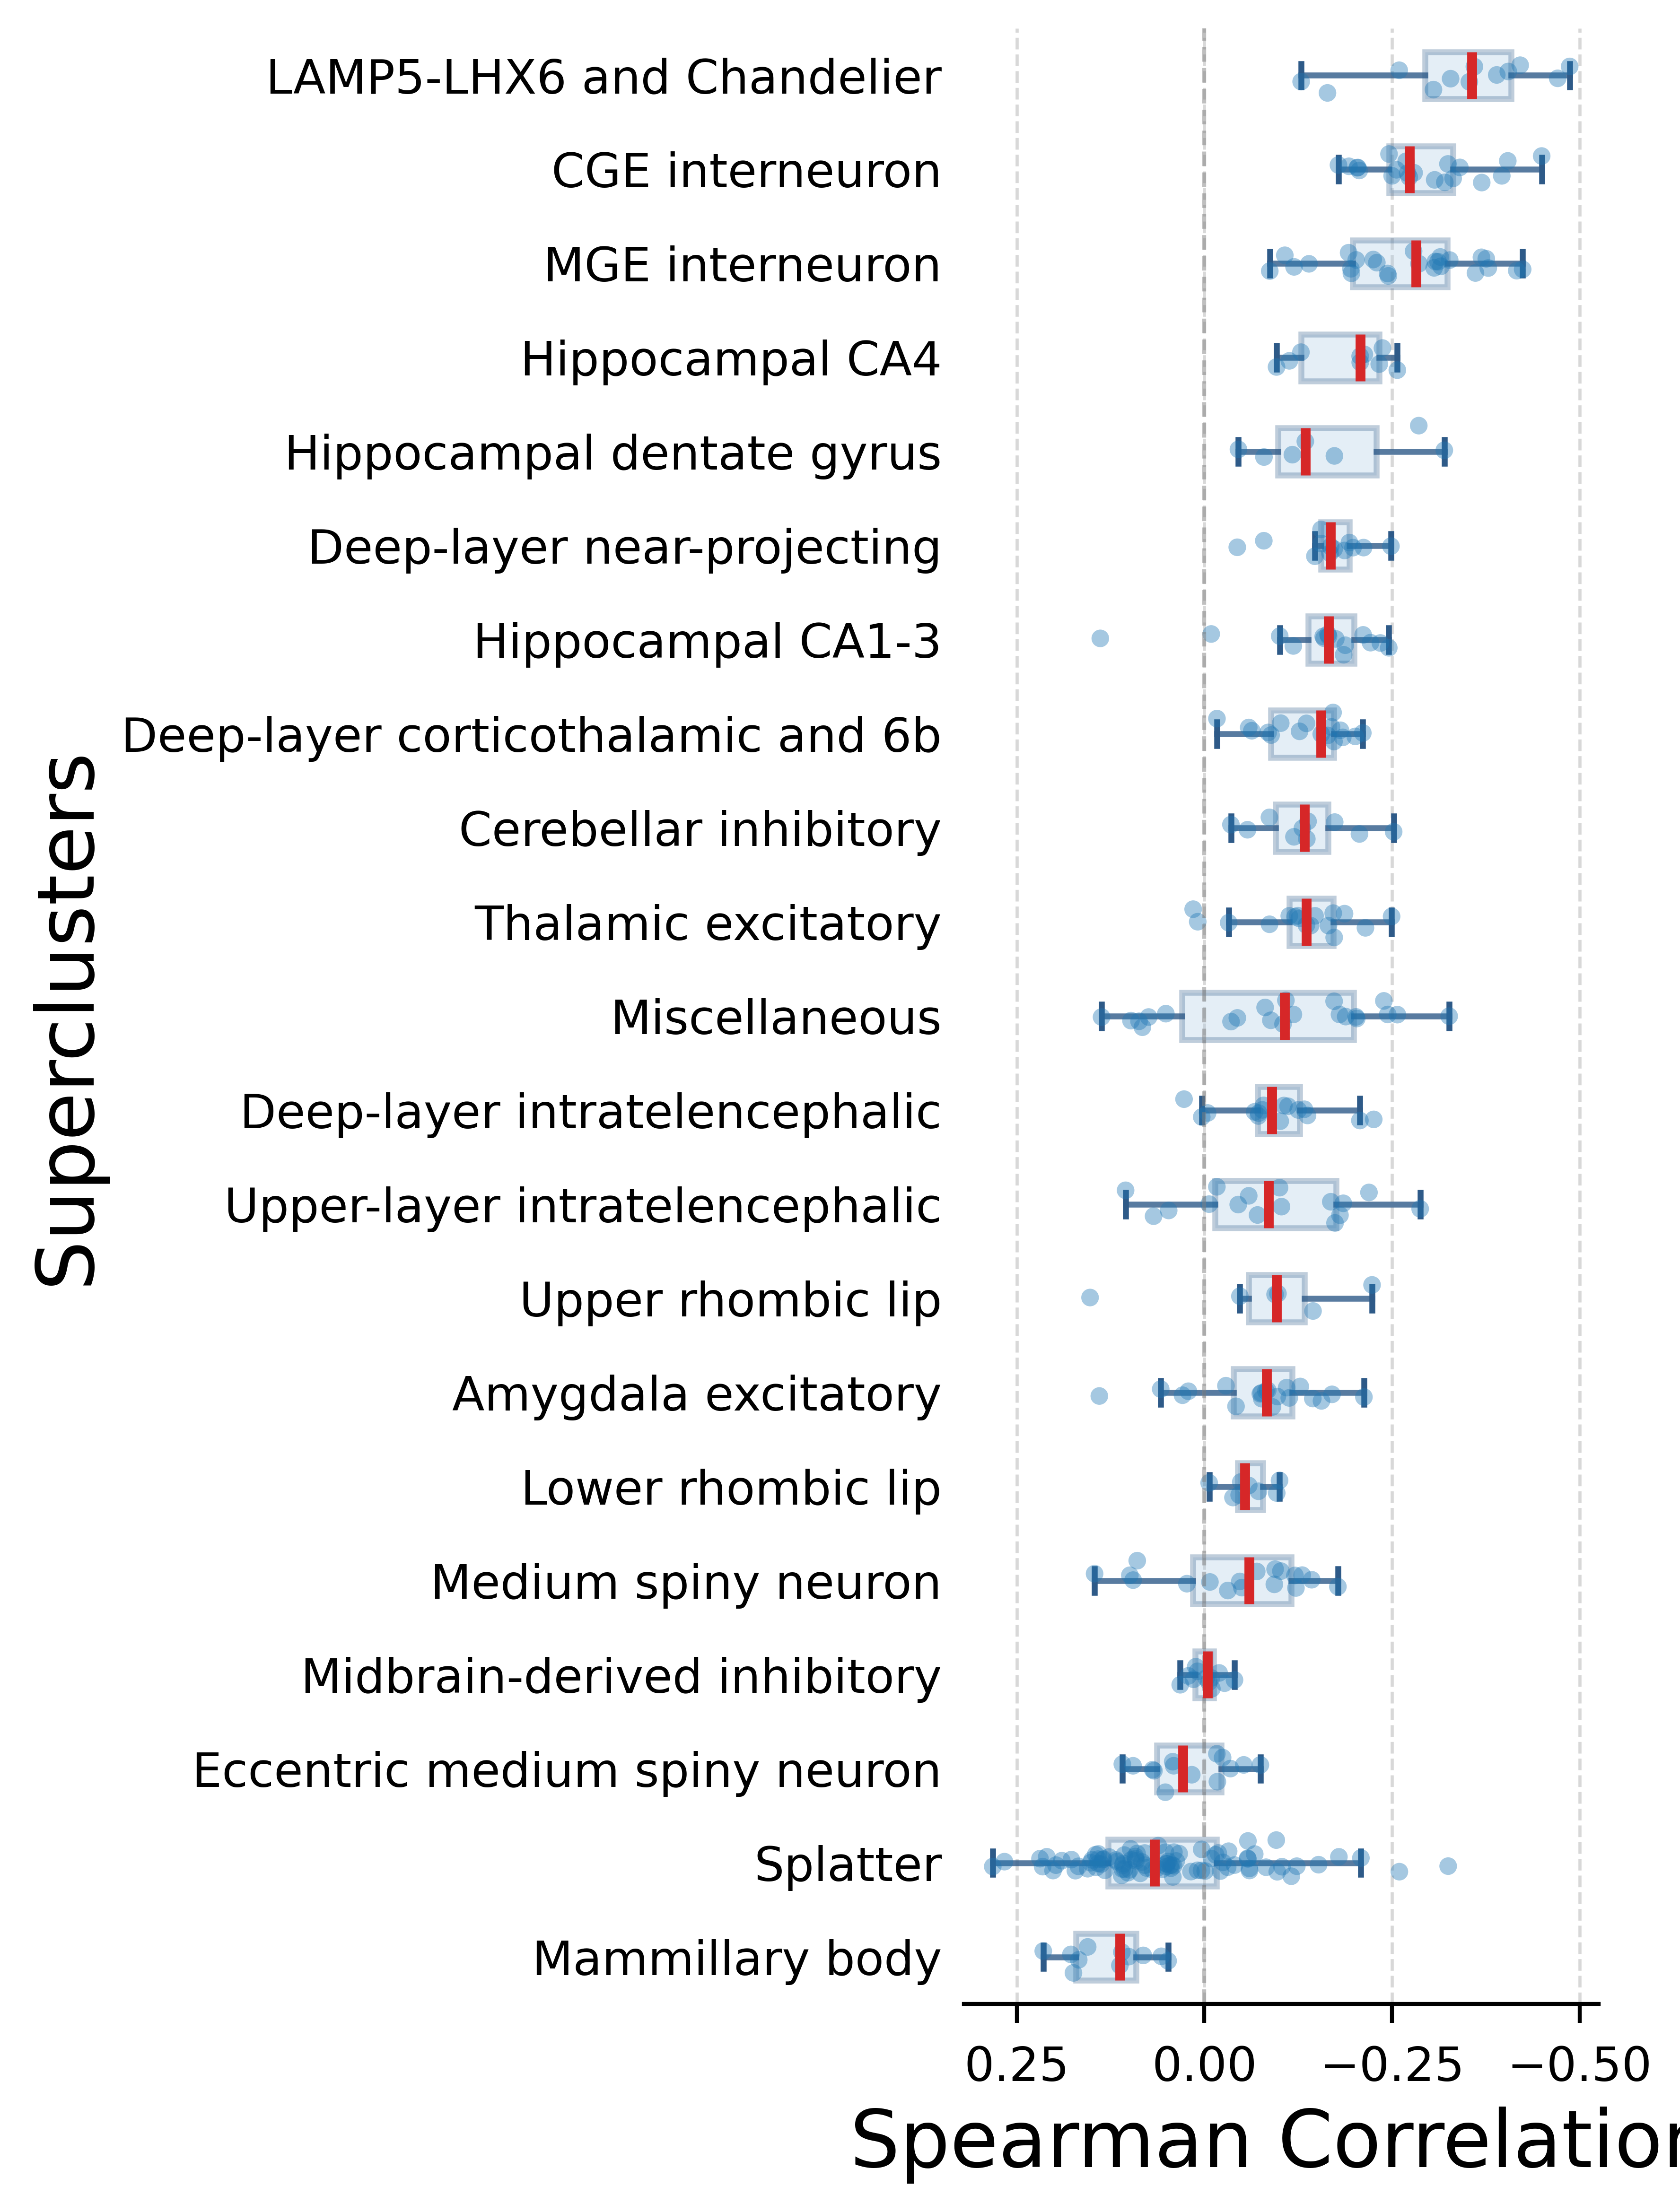

In [119]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=True, figsize=(6, 8), plot_metric="SpearmanR")

/tmp/ipykernel_37119/3403990755.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


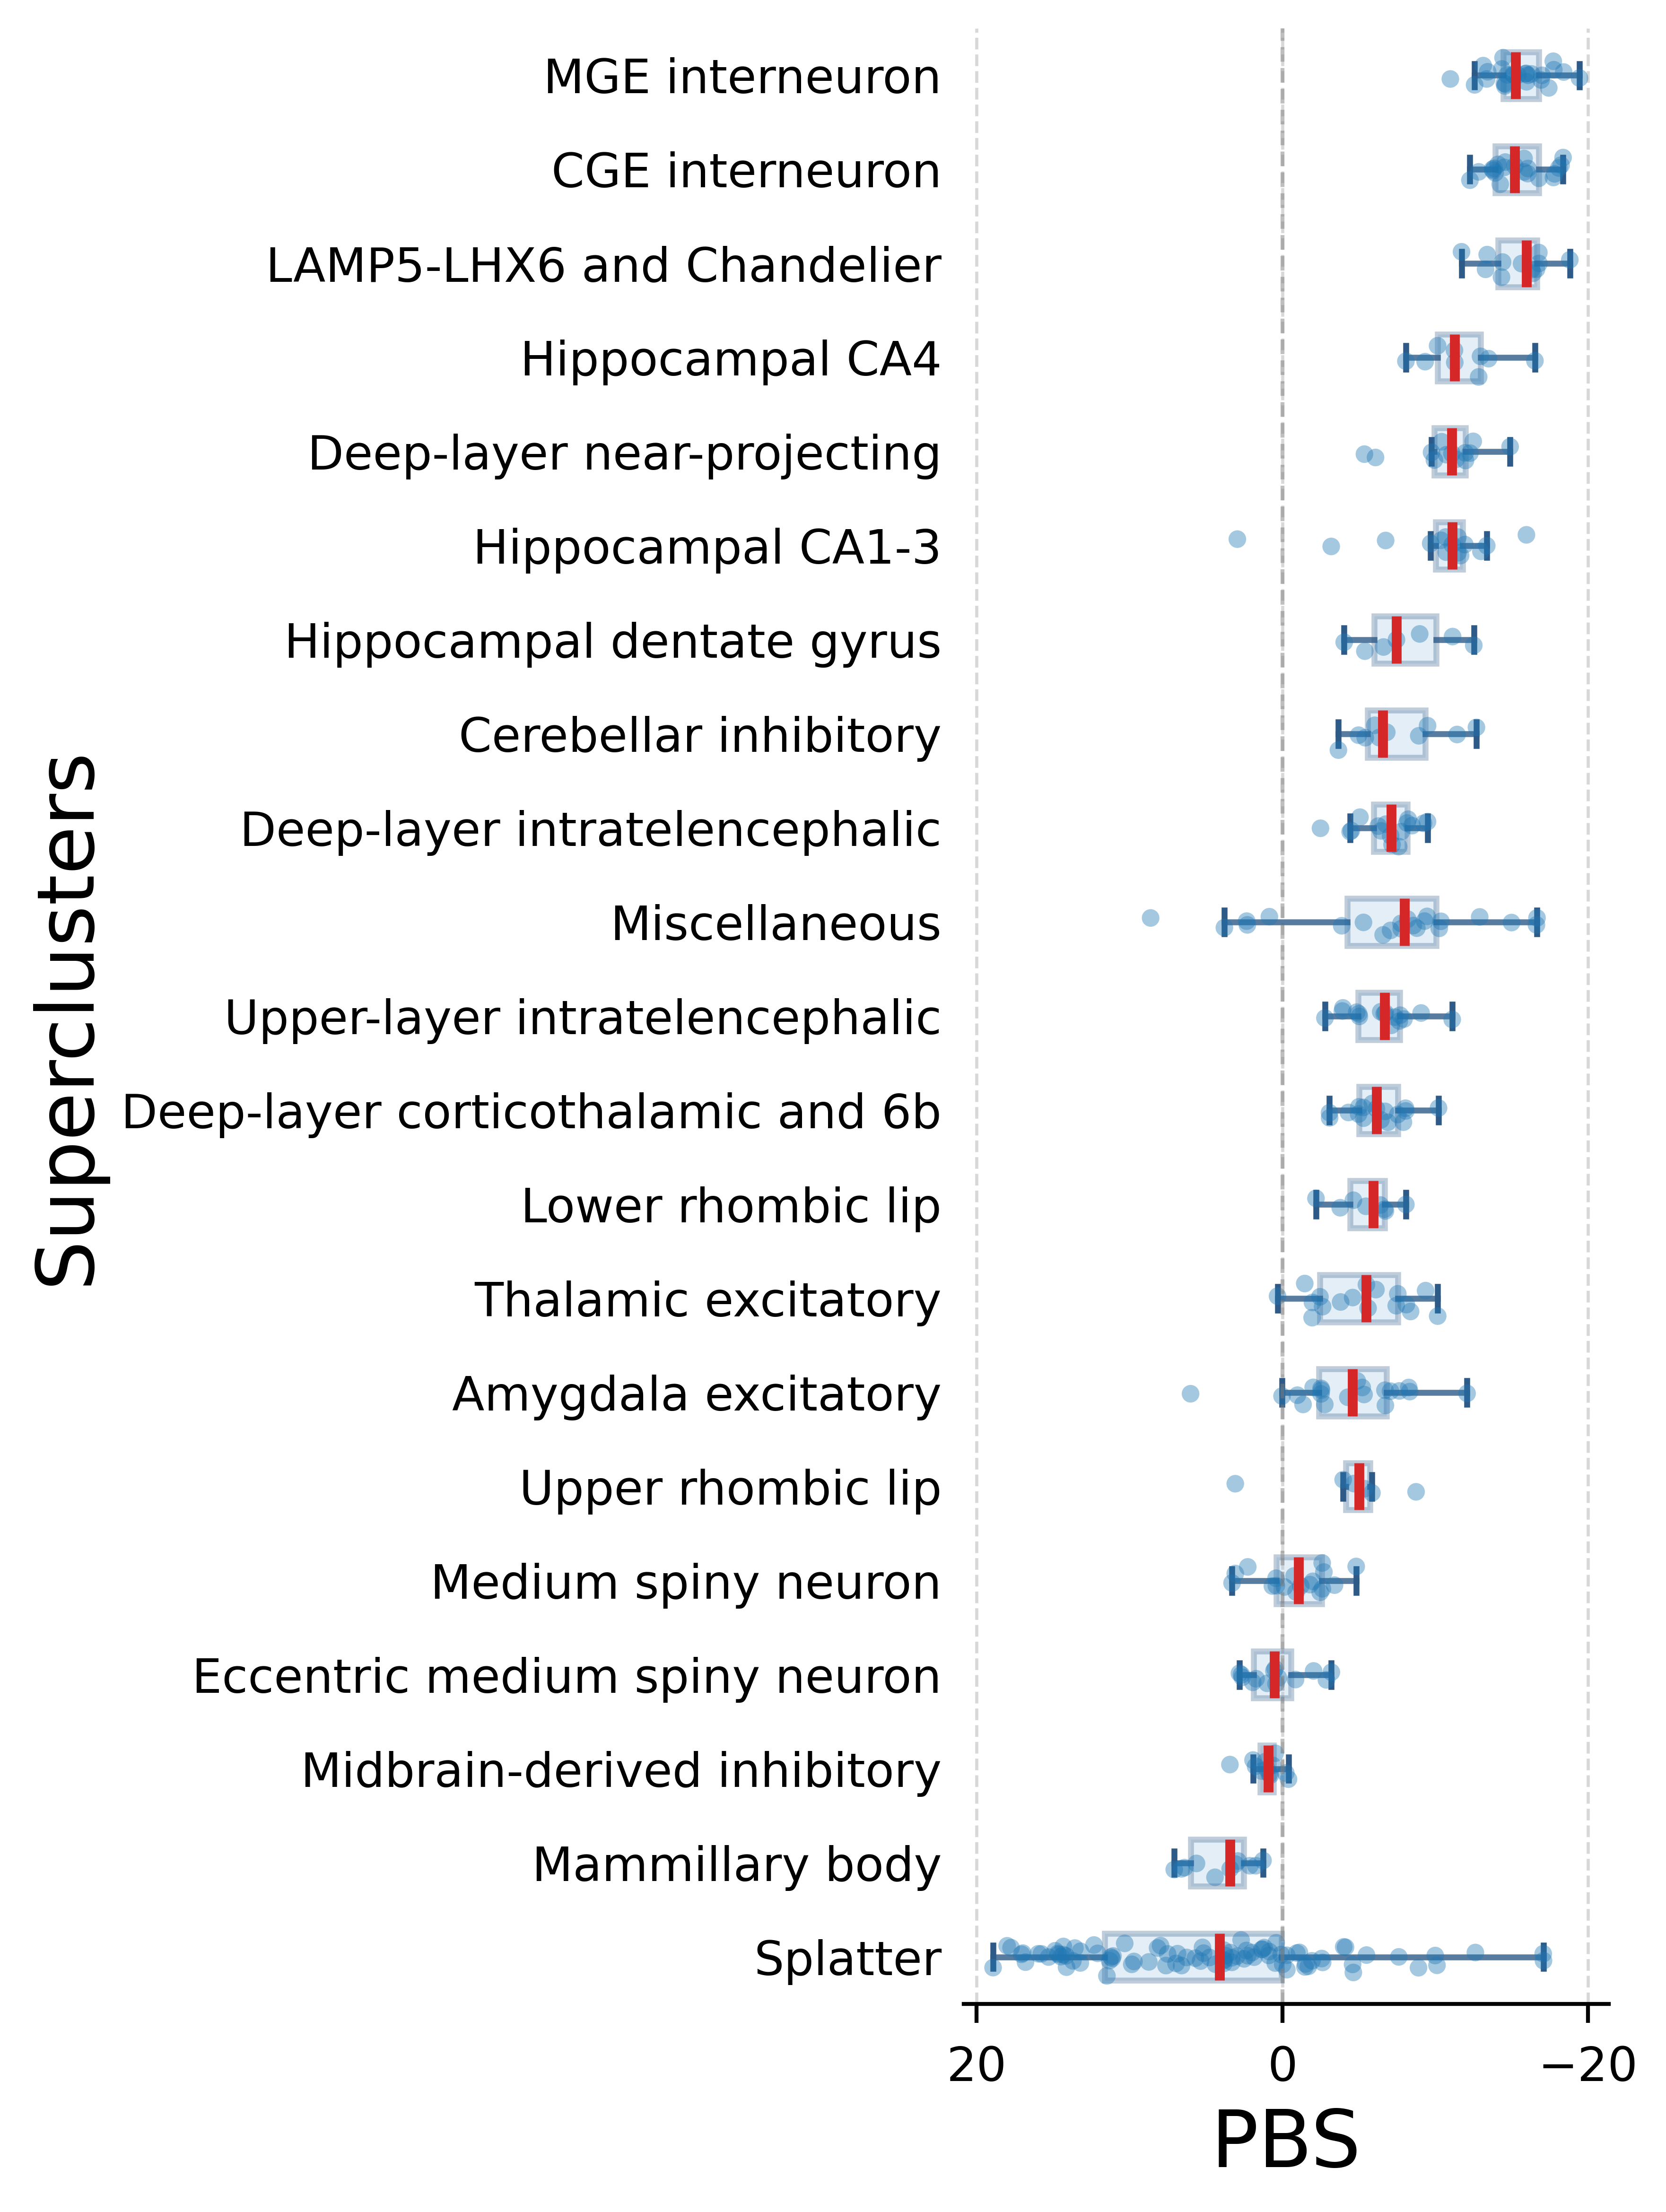

In [120]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=True, figsize=(6, 8), plot_metric="beta")

In [121]:
VIP_Anno = pd.read_csv("VIP_Anno.csv", index_col=0)

In [122]:
# Get subset of rows from VIP_Anno that exist in X22q_Z2_Bias_PT
common_indices = HumanCT_res_df_GeneL.index.intersection(VIP_Anno.index)
HumanCT_res_df_GeneL_sub = HumanCT_res_df_GeneL.loc[common_indices].copy()
HumanCT_res_df_GeneL_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

/tmp/ipykernel_37119/4052673592.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


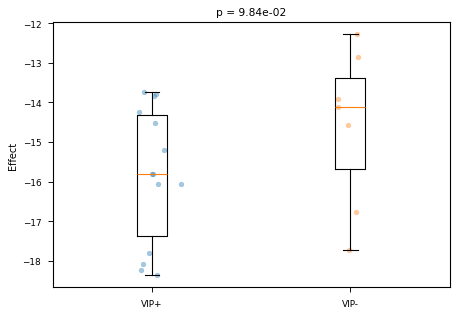

In [214]:
HumanCT_res_df_GeneL_sub_VIP_pos = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] >= 1]
HumanCT_res_df_GeneL_sub_VIP_neg = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] < 1]
# plot effect of VIP+ vs VIP-
data = [HumanCT_res_df_GeneL_sub_VIP_pos["beta"], HumanCT_res_df_GeneL_sub_VIP_neg["beta"]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(HumanCT_res_df_GeneL_sub_VIP_pos["beta"], 
                                    HumanCT_res_df_GeneL_sub_VIP_neg["beta"], alternative="less")
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([HumanCT_res_df_GeneL_sub_VIP_pos["beta"], HumanCT_res_df_GeneL_sub_VIP_neg["beta"]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()


/tmp/ipykernel_37119/3396741605.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


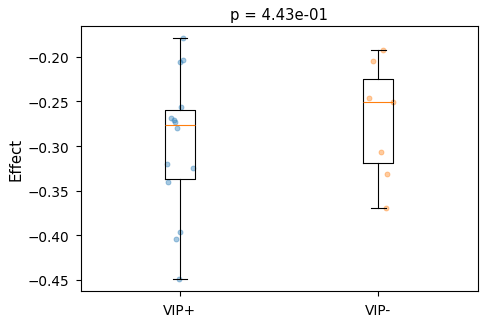

In [124]:
Effect = "SpearmanR"
HumanCT_res_df_GeneL_sub_VIP_pos = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] >= 1]
HumanCT_res_df_GeneL_sub_VIP_neg = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] < 1]
# plot effect of VIP+ vs VIP-
data = [HumanCT_res_df_GeneL_sub_VIP_pos[Effect], HumanCT_res_df_GeneL_sub_VIP_neg[Effect]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(HumanCT_res_df_GeneL_sub_VIP_pos[Effect], 
                                    HumanCT_res_df_GeneL_sub_VIP_neg[Effect])
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([HumanCT_res_df_GeneL_sub_VIP_pos[Effect], HumanCT_res_df_GeneL_sub_VIP_neg[Effect]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()

### Mut IQ permutation

In [125]:
#Perm_DIR = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/ALL/"
#Perm_DIR = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25_Seed42/ALL/"
Perm_DIR = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_June13/ALL/"
Perm_DFs = []
for df in os.listdir(Perm_DIR):
    df = pd.read_csv(f"{Perm_DIR}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs.append(df)
print(len(Perm_DFs))


10000


In [127]:
def plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=276, plot=False):
    """
    Plot null distributions of Rho and Beta values compared to observed values for a given cell type.
    
    Parameters:
    -----------
    HumanCT_res_df_GeneL : pandas DataFrame
        DataFrame containing observed results
    Perm_DFs : list
        List of DataFrames containing permutation results
    CT : int
        Cell type ID to analyze (default: 276)
    """
    Obs_Rho = HumanCT_res_df_GeneL.loc[CT, "SpearmanR"]
    Obs_Beta = HumanCT_res_df_GeneL.loc[CT, "beta"]
    
    Null_Rho = []
    Null_Beta = []
    for df in Perm_DFs:
        Null_Rho.append(df.loc[CT, "SpearmanR"])
        Null_Beta.append(df.loc[CT, "beta"])
    Null_Rho = np.array(Null_Rho)
    Null_Beta = np.array(Null_Beta)
    # Calculate p-values
    p_rho = (Null_Rho <= Obs_Rho).mean()
    p_beta = (Null_Beta <= Obs_Beta).mean()
    
    if plot:
        # Create plots comparing observed values to null distributions
        plt.figure(figsize=(10,5))

        # Plot Rho distribution and observed value
        plt.subplot(121)
        plt.hist(Null_Rho, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Rho, color='red', linestyle='--', label='Observed')
        plt.xlabel('Rho')
        plt.ylabel('Count')
        plt.text(0.60, 0.60, f'p_rho = {p_rho:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.title('Rho: Null Distribution vs Observed')
        plt.legend()

        # Plot Beta distribution and observed value  
        plt.subplot(122)
        plt.hist(Null_Beta, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Beta, color='red', linestyle='--', label='Observed')
        plt.xlabel('Beta')
        plt.ylabel('Count')
        plt.title('Beta: Null Distribution vs Observed')
        plt.legend()
    # annotate p-values

        plt.text(0.60, 0.60, f'p_beta = {p_beta:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.tight_layout()
        plt.show()
    
    return p_rho, p_beta

def plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=False):

    Obs_Rho = HumanCT_res_df_GeneL.loc[ClusterIdx, "SpearmanR"].mean()
    Obs_Beta = HumanCT_res_df_GeneL.loc[ClusterIdx, "beta"].mean()
    

    Null_Rho = []
    Null_Beta = []
    for df in Perm_DFs:
        Null_Rho.append(df.loc[ClusterIdx, "SpearmanR"].mean())
        Null_Beta.append(df.loc[ClusterIdx, "beta"].mean())
    Null_Rho = np.array(Null_Rho)
    Null_Beta = np.array(Null_Beta)
    # Calculate p-values
    p_rho = (Null_Rho <= Obs_Rho).mean()
    p_beta = (Null_Beta <= Obs_Beta).mean()

    
    if plot:
        # Create plots comparing observed values to null distributions
        plt.figure(figsize=(10,5))

        # Plot Rho distribution and observed value
        plt.subplot(121)
        plt.hist(Null_Rho, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Rho, color='red', linestyle='--', label='Observed')
        plt.xlabel('Rho')
        plt.ylabel('Count')
        plt.text(0.60, 0.60, f'p_rho = {p_rho:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.title('Rho: Null Distribution vs Observed')
        plt.legend()

        # Plot Beta distribution and observed value  
        plt.subplot(122)
        plt.hist(Null_Beta, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Beta, color='red', linestyle='--', label='Observed')
        plt.xlabel('Beta')
        plt.ylabel('Count')
        plt.title('Beta: Null Distribution vs Observed')
        plt.legend()
    # annotate p-values

        plt.text(0.60, 0.60, f'p_beta = {p_beta:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.tight_layout()
        plt.show()
    
    return p_rho, p_beta

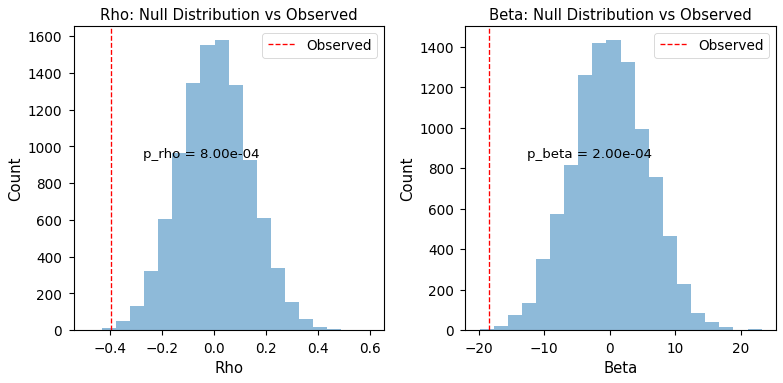

(0.0008, 0.0002)

In [128]:
plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=295, plot=True)

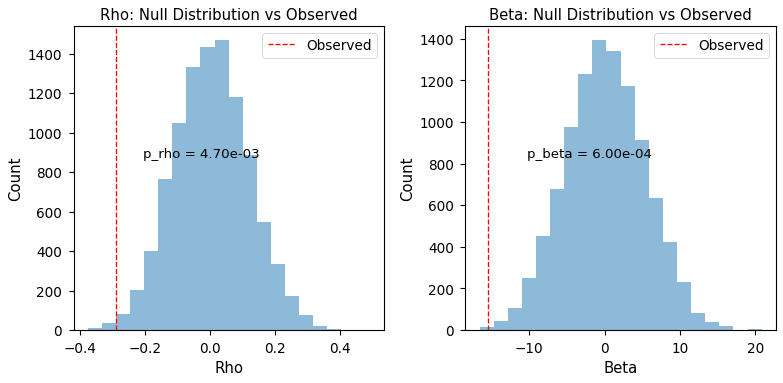

In [129]:
Supercluster = "CGE interneuron"
ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values

p_rho, p_beta = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=True)

In [130]:
#Supercluster = "CGE interneuron"
# Create DataFrame to store results
results_df = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho, p_beta = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=False)
    
    # Add results to DataFrame
    results_df = results_df.append({
        'Supercluster': Supercluster,
        "mean_PBS": HumanCT_res_df_GeneL.loc[ClusterIdx, "beta"].mean(),
        'p_rho': p_rho,
        'p_beta': p_beta
    }, ignore_index=True)

/tmp/ipykernel_37119/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_37119/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_37119/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_37119/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_37119/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  res

In [131]:
# Add FDR corrected p-values
results_df['p_rho_FDR'] = multipletests(results_df['p_rho'], method='fdr_bh')[1]
results_df['p_beta_FDR'] = multipletests(results_df['p_beta'], method='fdr_bh')[1]

results_df.sort_values("p_beta")

,Supercluster,p_rho,p_beta,mean_PBS,p_rho_FDR,p_beta_FDR
1,CGE interneuron,0.0047,0.0006,-15.419037,0.049350,0.012600
10,LAMP5-LHX6 and Chandelier,0.0019,0.0015,-15.374304,0.039900,0.015750
12,MGE interneuron,0.0090,0.0024,-15.428117,0.063000,0.016800
8,Hippocampal CA4,0.0715,0.0116,-11.769164,0.250950,0.060900
7,Hippocampal CA1-3,0.0945,0.0164,-9.898502,0.250950,0.068880
16,Miscellaneous,0.0728,0.0203,-6.665898,0.250950,0.071050
5,Deep-layer near-projecting,0.0956,0.0295,-10.643747,0.250950,0.086362
9,Hippocampal dentate gyrus,0.0932,0.0329,-8.023036,0.250950,0.086362
2,Cerebellar inhibitory,0.1210,0.0383,-7.582115,0.257670,0.089367
20,Upper-layer intratelencephalic,0.1958,0.0851,-6.460426,0.316292,0.169336


In [132]:
for i, row in HumanCT_res_df_GeneL.iterrows():
    ct = int(row["CT"])
    p_rho, p_beta = plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=ct, plot=False)
    HumanCT_res_df_GeneL.loc[i, "p_rho_perm"] = p_rho
    HumanCT_res_df_GeneL.loc[i, "p_beta_perm"] = p_beta
#HumanCT_res_df_GeneL.sort_values("p_beta_FDR")

In [133]:
HumanCT_res_df_GeneL_neuron = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"].isin(Neurons)]

In [134]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("p_beta_perm")
HumanCT_res_df_GeneL_neuron = HumanCT_res_df_GeneL_neuron.sort_values("p_beta_perm")
print(HumanCT_res_df_GeneL.shape, HumanCT_res_df_GeneL_neuron.shape)


(461, 15) (382, 15)


In [146]:
HumanCT_res_df_GeneL["p_beta_perm_Log"] = HumanCT_res_df_GeneL["p_beta_perm"].apply(lambda x: -np.log10(x))

In [149]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("p_beta_perm")
HumanCT_res_df_GeneL.head(5)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR,p_beta_perm_Log
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330,0.0001,0.0000,0.015367,0.000000,inf
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,0.015367,0.015367,4.00000
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708,0.0005,0.0002,0.046100,0.015367,3.69897
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977,0.0008,0.0002,0.046100,0.015367,3.69897
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181,0.0006,0.0002,0.046100,0.015367,3.69897


/tmp/ipykernel_37119/3403990755.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


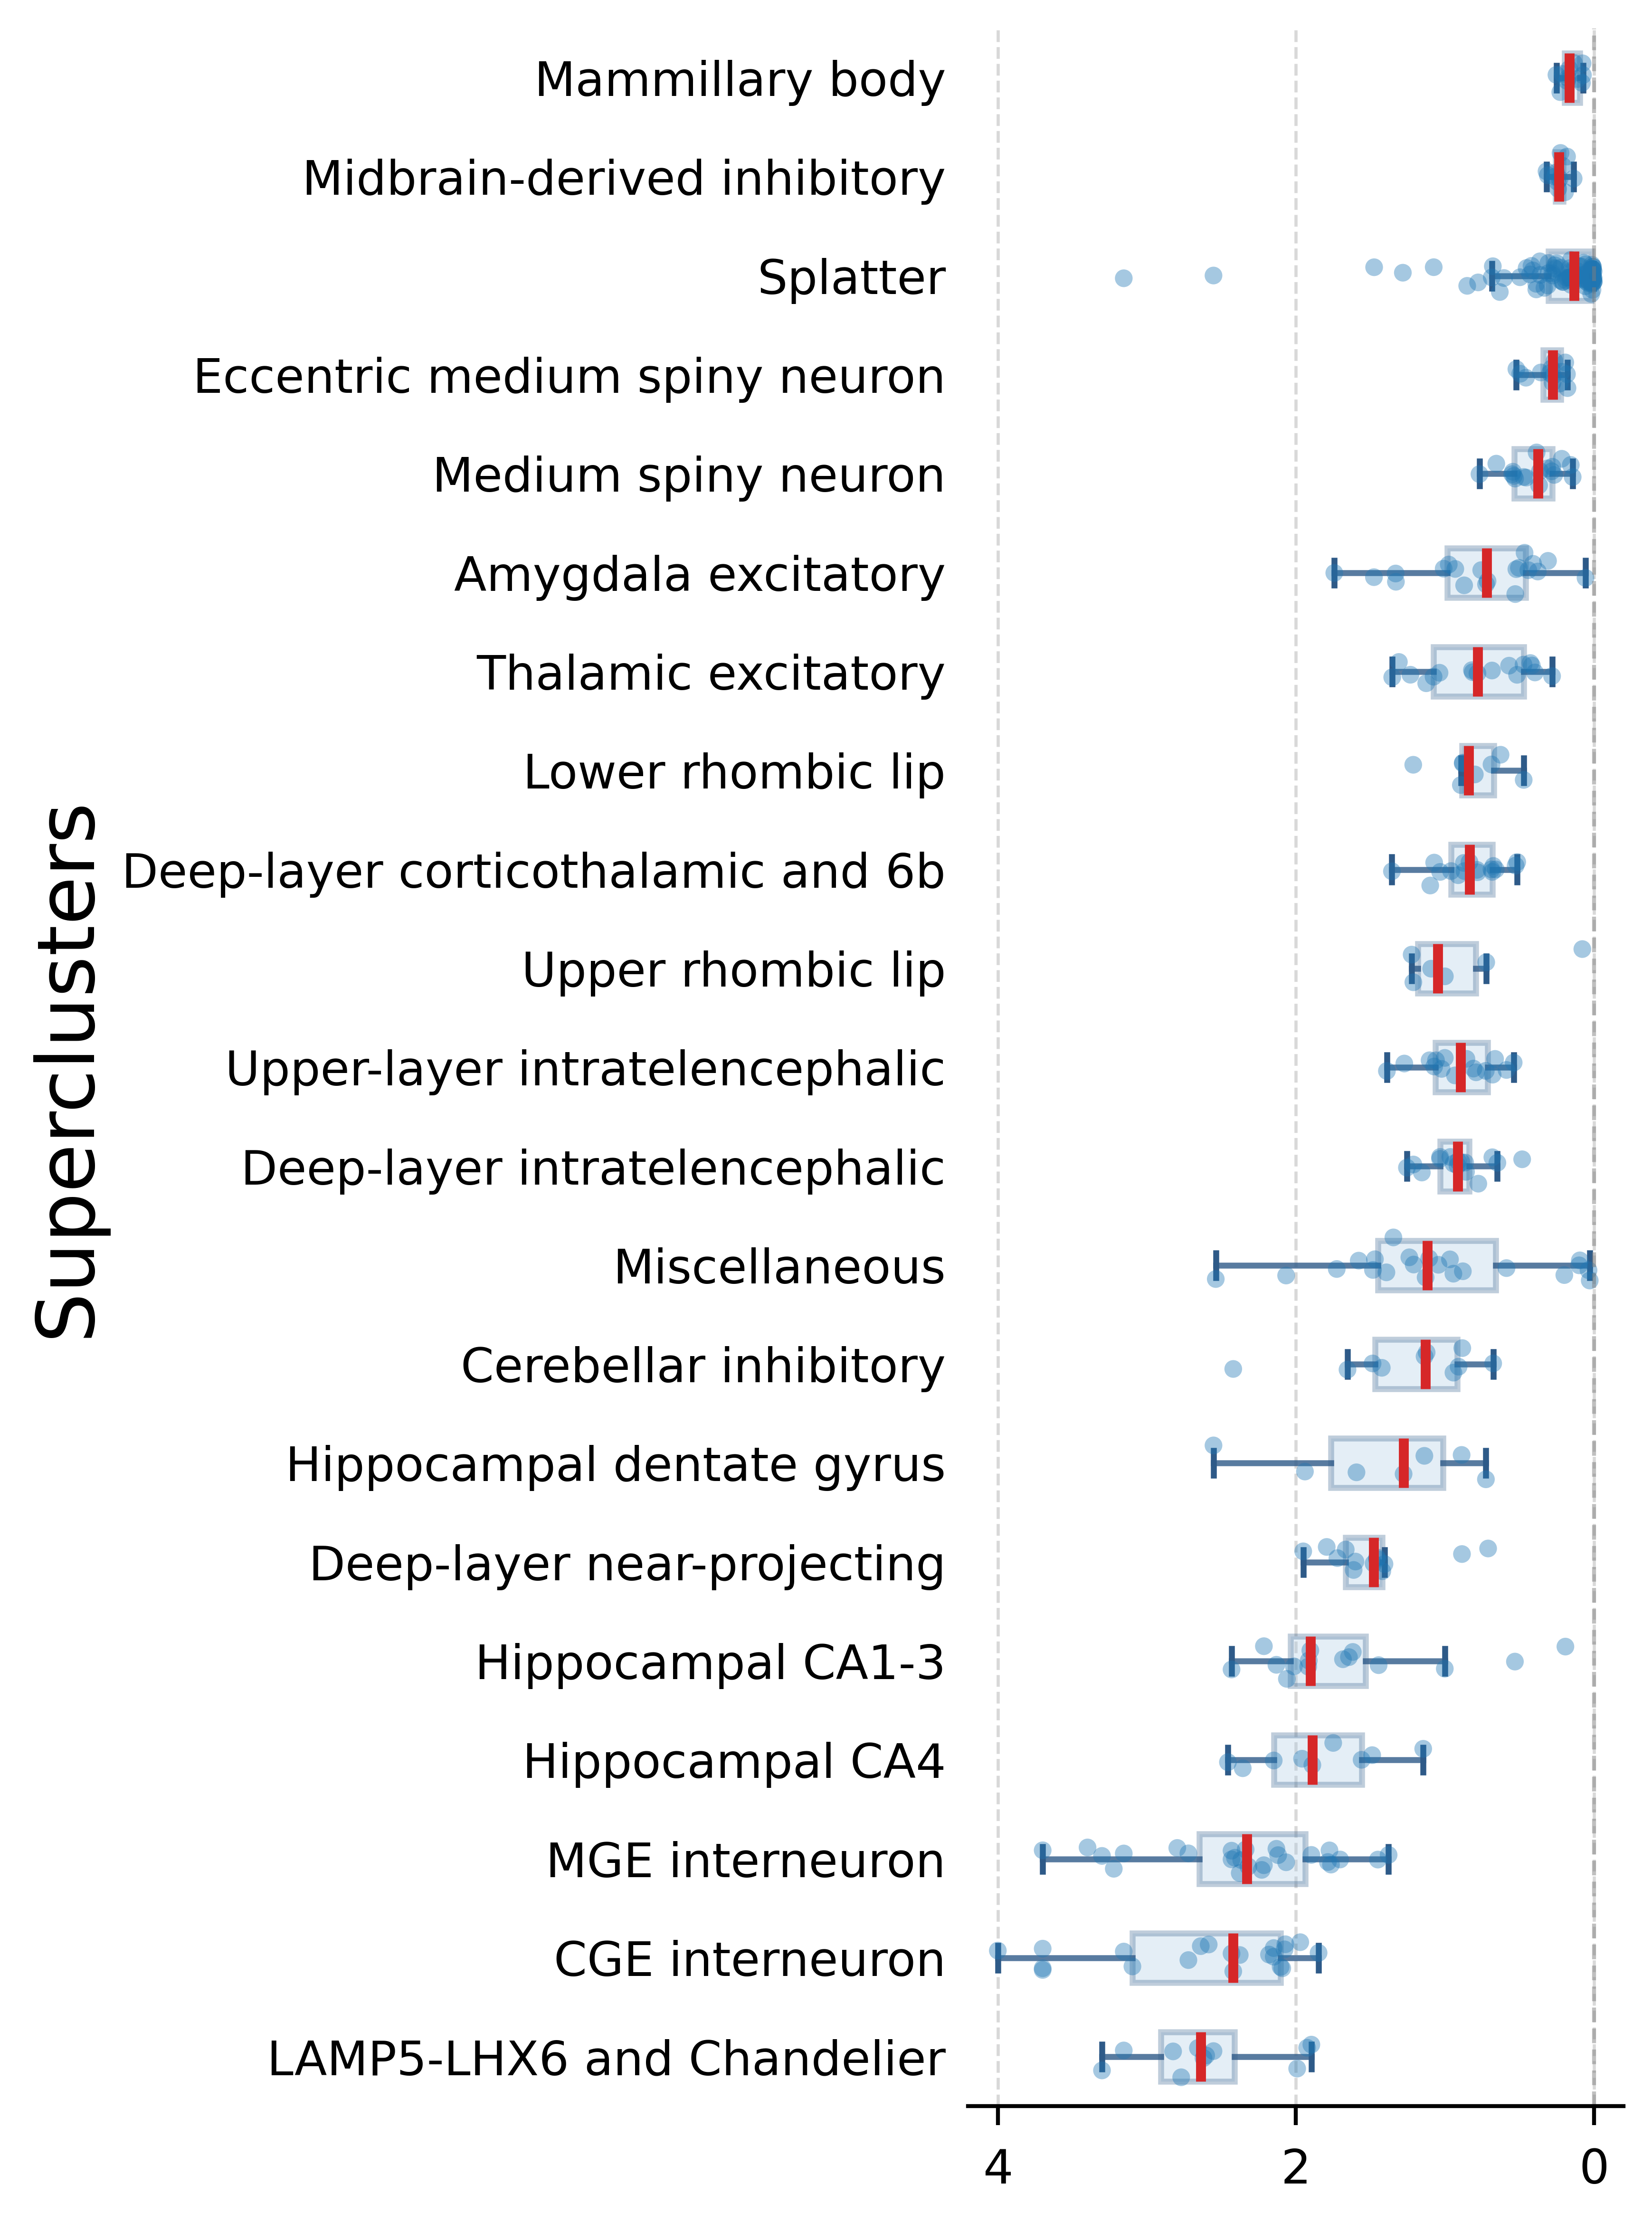

In [147]:
#umanCT_res_df_GeneL
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=True, figsize=(6, 8), plot_metric="p_beta_perm_Log")

In [135]:
HumanCT_res_df_GeneL['p_rho_perm_FDR'] = multipletests(HumanCT_res_df_GeneL['p_rho_perm'], method='fdr_bh')[1]
HumanCT_res_df_GeneL['p_beta_perm_FDR'] = multipletests(HumanCT_res_df_GeneL['p_beta_perm'], method='fdr_bh')[1]

HumanCT_res_df_GeneL_neuron['p_rho_perm_FDR'] = multipletests(HumanCT_res_df_GeneL_neuron['p_rho_perm'], method='fdr_bh')[1]
HumanCT_res_df_GeneL_neuron['p_beta_perm_FDR'] = multipletests(HumanCT_res_df_GeneL_neuron['p_beta_perm'], method='fdr_bh')[1]

In [136]:
HumanCT_res_df_GeneL_neuron.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330,0.0001,0.0000,0.012733,0.000000
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,0.012733,0.012733
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727,0.0064,0.0002,0.118238,0.012733
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708,0.0005,0.0002,0.038200,0.012733
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181,0.0006,0.0002,0.038200,0.012733
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977,0.0008,0.0002,0.038200,0.012733
239,239,MGE interneuron,-0.424077,0.001125,-0.405046,0.001957,-16.983547,-27.442845,-6.524249,65.529179,0.164062,0.001957,5.216921,0.0008,0.0004,0.038200,0.019100
268,268,LAMP5-LHX6 and Chandelier,-0.420761,0.001242,-0.387999,0.003129,-16.778903,-27.653043,-5.904763,65.083869,0.150543,0.003129,5.423838,0.0004,0.0005,0.038200,0.019100
236,236,MGE interneuron,-0.375602,0.004336,-0.391401,0.002855,-19.434111,-31.900093,-6.968130,64.516750,0.153194,0.002855,6.217822,0.0021,0.0005,0.068760,0.019100
260,260,MGE interneuron,-0.369149,0.005114,-0.371696,0.004793,-16.926226,-28.460170,-5.392282,64.769167,0.138158,0.004793,5.752937,0.0027,0.0006,0.068760,0.019100


In [137]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("beta")

In [138]:
HumanCT_res_df_GeneL.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR
236,236,MGE interneuron,-0.375602,0.004336,-0.391401,0.002855,-19.434111,-31.900093,-6.968130,64.516750,0.153194,0.002855,6.217822,0.0021,0.0005,0.082980,0.023050
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330,0.0001,0.0000,0.015367,0.000000
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708,0.0005,0.0002,0.046100,0.015367
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977,0.0008,0.0002,0.046100,0.015367
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181,0.0006,0.0002,0.046100,0.015367
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,0.015367,0.015367
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727,0.0064,0.0002,0.142690,0.015367
240,240,MGE interneuron,-0.378241,0.004050,-0.383223,0.003554,-17.758245,-29.435741,-6.080749,65.525407,0.146860,0.003554,5.824538,0.0026,0.0007,0.082980,0.023050
286,286,CGE interneuron,-0.306867,0.021426,-0.360944,0.006277,-17.734122,-30.235279,-5.232965,65.051352,0.130281,0.006277,6.235366,0.0125,0.0023,0.174621,0.046100
257,257,MGE interneuron,-0.225006,0.095461,-0.332159,0.012383,-17.722334,-31.452641,-3.992027,63.751094,0.110330,0.012383,6.848446,0.0465,0.0059,0.351418,0.061133


In [139]:
HumanCT_res_df_GeneL.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.cluster.June10.csv")
results_df.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.Supercluster.June10.csv")

In [140]:
HumanCT_res_df_GeneL.head(2)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR
236,236,MGE interneuron,-0.375602,0.004336,-0.391401,0.002855,-19.434111,-31.900093,-6.968130,64.516750,0.153194,0.002855,6.217822,0.0021,0.0005,0.082980,0.02305
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330,0.0001,0.0000,0.015367,0.00000


In [ ]:
MGE interneuron

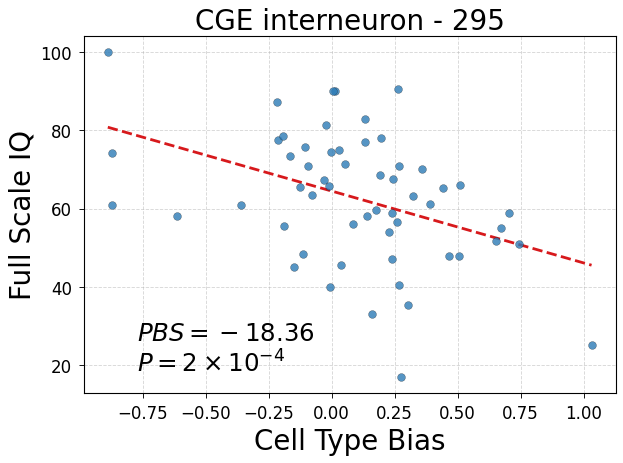

In [162]:
STR = 295
plt.style.use('seaborn-v0_8-paper')
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 6))
#Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HCT_Z2_MAT_HCT, ax=ax1)
#Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1, Pval=0.015367, textPos=(0.1, 0.2))
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1, Pval=0.0002, textPos=(0.1, 0.2))
plt.tight_layout()
plt.show()

In [164]:
VIP_Anno = pd.read_csv("VIP_Anno.csv", index_col=0)
common_indices = HumanCT_res_df_GeneL.index.intersection(VIP_Anno.index)
HumanCT_res_df_GeneL_sub = HumanCT_res_df_GeneL.loc[common_indices].copy()
HumanCT_res_df_GeneL_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

/tmp/ipykernel_37119/1521961861.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


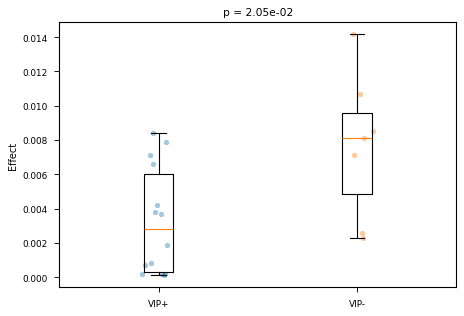

In [166]:
HumanCT_res_df_GeneL_sub_VIP_pos = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] >= 1]
HumanCT_res_df_GeneL_sub_VIP_neg = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] < 1]
# plot effect of VIP+ vs VIP-
EFFECT = "p_beta_perm"
data = [HumanCT_res_df_GeneL_sub_VIP_pos[EFFECT], HumanCT_res_df_GeneL_sub_VIP_neg[EFFECT]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(HumanCT_res_df_GeneL_sub_VIP_pos[EFFECT], 
                                    HumanCT_res_df_GeneL_sub_VIP_neg[EFFECT])
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([HumanCT_res_df_GeneL_sub_VIP_pos[EFFECT], HumanCT_res_df_GeneL_sub_VIP_neg[EFFECT]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()

In [206]:
HumanCT_res_df_GeneL_sub.sort_values(by="p_beta_perm_FDR", ascending=True).head(15)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR,p_beta_perm_Log,VIP
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,0.015367,0.015367,4.000000,8.779327
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977,0.0008,0.0002,0.046100,0.015367,3.698970,18.733238
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181,0.0006,0.0002,0.046100,0.015367,3.698970,21.116175
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727,0.0064,0.0002,0.142690,0.015367,3.698970,2.963595
296,296,CGE interneuron,-0.324526,0.014679,-0.372609,0.004683,-15.816929,-26.564324,-5.069533,64.606159,0.138837,0.004683,5.360620,0.0054,0.0007,0.131021,0.023050,3.154902,13.942251
293,293,CGE interneuron,-0.340386,0.010261,-0.371358,0.004835,-16.060417,-27.015917,-5.104917,64.342439,0.137907,0.004835,5.464419,0.0050,0.0008,0.128056,0.024587,3.096910,13.958615
280,280,CGE interneuron,-0.255926,0.056934,-0.353467,0.007533,-15.810068,-27.225595,-4.394541,65.568250,0.124939,0.007533,5.693872,0.0221,0.0019,0.242574,0.043795,2.721246,1.858206
286,286,CGE interneuron,-0.306867,0.021426,-0.360944,0.006277,-17.734122,-30.235279,-5.232965,65.051352,0.130281,0.006277,6.235366,0.0125,0.0023,0.174621,0.046100,2.638272,0.045906
278,278,CGE interneuron,-0.331442,0.012584,-0.354067,0.007425,-16.778167,-28.869239,-4.687095,65.965808,0.125363,0.007425,6.030823,0.0072,0.0026,0.144063,0.046100,2.585027,0.081232
292,292,CGE interneuron,-0.268893,0.045081,-0.344574,0.009307,-16.047040,-27.974765,-4.119316,63.594834,0.118731,0.009307,5.949348,0.0206,0.0038,0.238371,0.048592,2.420216,9.425919


In [190]:
HumanCT_res_df_GeneL_sub
FDR_cutoff = 0.05
N_VIP_Sig = HumanCT_res_df_GeneL_sub_VIP_pos[HumanCT_res_df_GeneL_sub_VIP_pos["p_beta_perm_FDR"]< FDR_cutoff].shape[0]
N_nonVIP_Sig = HumanCT_res_df_GeneL_sub_VIP_neg[HumanCT_res_df_GeneL_sub_VIP_neg["p_beta_perm_FDR"]< FDR_cutoff].shape[0]
N_total_VIP = HumanCT_res_df_GeneL_sub_VIP_pos.shape[0]
N_total_nonVIP = HumanCT_res_df_GeneL_sub_VIP_neg.shape[0]
print(f"VIP+: {N_VIP_Sig}/{N_total_VIP}, VIP-: {N_nonVIP_Sig}/{N_total_nonVIP}")
print(f"VIP+: {N_VIP_Sig/N_total_VIP}, VIP-: {N_nonVIP_Sig/N_total_nonVIP}")

VIP+: 10/14, VIP-: 2/7
VIP+: 0.7142857142857143, VIP-: 0.2857142857142857


In [191]:
# Test if N_VIP_Sig is significantly more than expected by chance using a binomial test
from scipy.stats import binom_test

# Assume the expected proportion of significant genes is the same as in VIP- group
expected_prop = N_nonVIP_Sig / N_total_nonVIP if N_total_nonVIP > 0 else 0
#expected_prop = (2+10) / (14 + 7)
print(expected_prop)

# Perform one-sided binomial test: is N_VIP_Sig greater than expected under null?
p_binom = binom_test(N_VIP_Sig, N_total_VIP, expected_prop, alternative='greater')

print(f"Binomial test p-value (VIP+ > expected): {p_binom:.3g}")
N_VIP_Sig, N_nonVIP_Sig, N_total_VIP, N_total_nonVIP

0.2857142857142857
Binomial test p-value (VIP+ > expected): 0.0011


/tmp/ipykernel_37119/3408906940.py:10: DeprecationWarning: 'binom_test' is deprecated in favour of 'binomtest' from version 1.7.0 and will be removed in Scipy 1.12.0.
  p_binom = binom_test(N_VIP_Sig, N_total_VIP, expected_prop, alternative='greater')


(10, 2, 14, 7)

In [192]:
# Test if VIP+ is associated with being significant using Fisher's exact test
from scipy.stats import fisher_exact

# Construct contingency table:
#            Significant   Not Significant
# VIP+       N_VIP_Sig     N_total_VIP - N_VIP_Sig
# VIP-       N_nonVIP_Sig  N_total_nonVIP - N_nonVIP_Sig
contingency_table = [
    [N_VIP_Sig, N_total_VIP - N_VIP_Sig],
    [N_nonVIP_Sig, N_total_nonVIP - N_nonVIP_Sig]
]

# Perform Fisher's exact test (test for enrichment of significance in VIP+)
oddsratio, p_fisher = fisher_exact(contingency_table, alternative='greater')

print(f"Fisher's exact test p-value (VIP+ enrichment for significance): {p_fisher:.3g}")
print("Contingency table:")
print(f"         Significant  Not Significant")
print(f"VIP+     {N_VIP_Sig:<12} {N_total_VIP - N_VIP_Sig}")
print(f"VIP-     {N_nonVIP_Sig:<12} {N_total_nonVIP - N_nonVIP_Sig}")
print(f"Odds ratio: {oddsratio:.3g}")
N_VIP_Sig, N_nonVIP_Sig, N_total_VIP, N_total_nonVIP

Fisher's exact test p-value (VIP+ enrichment for significance): 0.0805
Contingency table:
         Significant  Not Significant
VIP+     10           4
VIP-     2            5
Odds ratio: 6.25


(10, 2, 14, 7)

In [193]:
# Is Fisher's exact test the most powerful here?
# For small sample sizes or when expected counts are low, Fisher's exact test is appropriate and provides an exact p-value.
# For larger sample sizes, a chi-squared test of independence may have more power, but can be inaccurate if expected counts are small.
# Here, we use both tests for comparison.

from scipy.stats import fisher_exact, chi2_contingency

# Construct contingency table:
#            Significant   Not Significant
# VIP+       N_VIP_Sig     N_total_VIP - N_VIP_Sig
# VIP-       N_nonVIP_Sig  N_total_nonVIP - N_nonVIP_Sig
contingency_table = [
    [N_VIP_Sig, N_total_VIP - N_VIP_Sig],
    [N_nonVIP_Sig, N_total_nonVIP - N_nonVIP_Sig]
]

# Fisher's exact test (exact, best for small samples or low expected counts)
oddsratio, p_fisher = fisher_exact(contingency_table, alternative='greater')

# Chi-squared test (approximate, more powerful for large samples)
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table, correction=False)

print(f"Fisher's exact test p-value (VIP+ enrichment for significance): {p_fisher:.3g}")
print(f"Chi-squared test p-value: {p_chi2:.3g}")
print("Contingency table:")
print(f"         Significant  Not Significant")
print(f"VIP+     {N_VIP_Sig:<12} {N_total_VIP - N_VIP_Sig}")
print(f"VIP-     {N_nonVIP_Sig:<12} {N_total_nonVIP - N_nonVIP_Sig}")
print(f"Odds ratio (Fisher): {oddsratio:.3g}")
print(f"Expected counts (chi2):\n{expected}")
N_VIP_Sig, N_nonVIP_Sig, N_total_VIP, N_total_nonVIP

Fisher's exact test p-value (VIP+ enrichment for significance): 0.0805
Chi-squared test p-value: 0.0614
Contingency table:
         Significant  Not Significant
VIP+     10           4
VIP-     2            5
Odds ratio (Fisher): 6.25
Expected counts (chi2):
[[8. 6.]
 [4. 3.]]


(10, 2, 14, 7)

In [195]:
# Barnard's Exact Test for 2x2 tables (more powerful than Fisher's for some cases)
# Note: scipy does not implement Barnard's test as of 2024. Use 'barnard_exact' from statsmodels if available.

from scipy.stats import fisher_exact
try:
    from statsmodels.stats.contingency_tables import barnard_exact
    barnard_available = True
except ImportError:
    barnard_available = False

# Construct contingency table:
#            Significant   Not Significant
# VIP+       N_VIP_Sig     N_total_VIP - N_VIP_Sig
# VIP-       N_nonVIP_Sig  N_total_nonVIP - N_nonVIP_Sig
contingency_table = [
    [N_VIP_Sig, N_total_VIP - N_VIP_Sig],
    [N_nonVIP_Sig, N_total_nonVIP - N_nonVIP_Sig]
]

# Fisher's exact test (for comparison)
oddsratio, p_fisher = fisher_exact(contingency_table, alternative='greater')

print(f"Fisher's exact test p-value (VIP+ enrichment for significance): {p_fisher:.3g}")
print(f"Contingency table:")
print(f"         Significant  Not Significant")
print(f"VIP+     {N_VIP_Sig:<12} {N_total_VIP - N_VIP_Sig}")
print(f"VIP-     {N_nonVIP_Sig:<12} {N_total_nonVIP - N_nonVIP_Sig}")
print(f"Odds ratio (Fisher): {oddsratio:.3g}")

# Barnard's exact test (if available)
if barnard_available:
    res = barnard_exact(contingency_table, alternative='greater')
    print(f"Barnard's exact test p-value (VIP+ enrichment for significance): {res.pvalue:.3g}")
    print(f"Barnard's test statistic: {res.statistic:.3g}")
else:
    print("Barnard's exact test is not available (requires statsmodels >= 0.13.0).")

N_VIP_Sig, N_nonVIP_Sig, N_total_VIP, N_total_nonVIP

Fisher's exact test p-value (VIP+ enrichment for significance): 0.0805
Contingency table:
         Significant  Not Significant
VIP+     10           4
VIP-     2            5
Odds ratio (Fisher): 6.25
Barnard's exact test is not available (requires statsmodels >= 0.13.0).


(10, 2, 14, 7)

In [210]:
import scipy.stats as stats
res = stats.fisher_exact([[11, 3], [2, 5]], alternative="greater")
print(res.pvalue)

0.04076367389060888


In [202]:
import scipy.stats as stats
res = stats.barnard_exact([[10, 4], [2, 5]], alternative="greater")
print(res.pvalue)

0.050614112906580556


In [203]:
import scipy.stats as stats
res = stats.boschloo_exact([[10, 4], [2, 5]], alternative="greater")
print(res.pvalue)

0.050686419334570056


In [208]:
def permutation_test(group1_success, group1_total, group2_success, group2_total, n_permutations=100000):
    """
    Permutation test for difference in proportions.
    """
    # Original data
    group1_data = [1] * group1_success + [0] * (group1_total - group1_success)
    group2_data = [1] * group2_success + [0] * (group2_total - group2_success)
    
    # Combine all data
    all_data = group1_data + group2_data
    n1, n2 = len(group1_data), len(group2_data)
    
    # Observed difference
    obs_diff = (group1_success / group1_total) - (group2_success / group2_total)
    
    print(f"Observed difference: {obs_diff:.4f}")
    print(f"Running {n_permutations:,} permutations...")
    
    # Permutation test
    extreme_count = 0
    random.seed(42)  # For reproducibility
    
    for i in range(n_permutations):
        # Randomly shuffle the combined data
        shuffled = random.sample(all_data, len(all_data))
        
        # Split back into two groups
        perm_group1 = shuffled[:n1]
        perm_group2 = shuffled[n1:]
        
        # Calculate difference for this permutation
        perm_diff = (sum(perm_group1) / n1) - (sum(perm_group2) / n2)
        
        # Count if as extreme or more extreme than observed
        if perm_diff >= obs_diff:  # One-tailed test
            extreme_count += 1
    
    p_value_perm = extreme_count / n_permutations
    
    return p_value_perm, obs_diff

# Run permutation test
p_perm, obs_diff = permutation_test(10, 14, 2, 7, n_permutations=1000000)
print(p_perm)

Observed difference: 0.4286
Running 1,000,000 permutations...
0.080462


#### Test VIP+ and VIP-

In [8]:
CGE_VIP_Pos_list = np.loadtxt("../dat/Other/CGE_VIP_Pos.txt", dtype=int)
CGE_VIP_Neg_list = np.loadtxt("../dat/Other/CGE_VIP_Neg.txt", dtype=int)

In [142]:
VIP_pos_meanPBS = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL.index.isin(CGE_VIP_Pos_list)]["beta"].mean()
VIP_neg_meanPBS = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL.index.isin(CGE_VIP_Neg_list)]["beta"].mean()
DIFF_obs = VIP_pos_meanPBS - VIP_neg_meanPBS
print(VIP_pos_meanPBS, VIP_neg_meanPBS, VIP_pos_meanPBS - VIP_neg_meanPBS)

-15.826193953107543 -14.604724139452458 -1.2214698136550854


In [143]:
null_diffs = []
for i in range(10000):
    tmpDF = Perm_DFs[i]
    tmp_VIP_pos_meanPBS = tmpDF[tmpDF.index.isin(CGE_VIP_Pos_list)]["beta"].mean()
    tmp_VIP_neg_meanPBS = tmpDF[tmpDF.index.isin(CGE_VIP_Neg_list)]["beta"].mean()
    null_diffs.append(tmp_VIP_pos_meanPBS - tmp_VIP_neg_meanPBS)
null_diffs = np.array(null_diffs)

Observed difference: -1.221
P-value: 2.834e-01


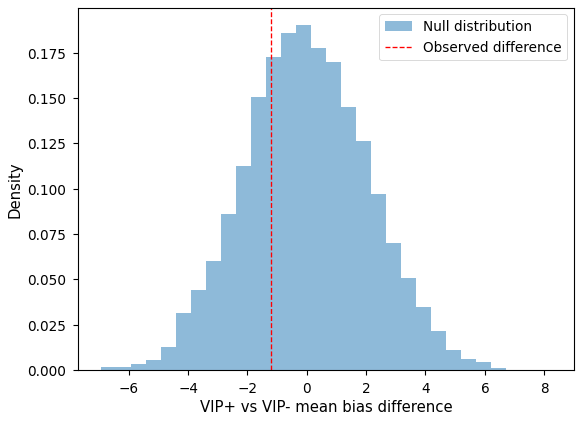

In [144]:
# Plot observed difference vs null distribution
plt.figure(figsize=(8,6))
plt.hist(null_diffs, bins=30, density=True, alpha=0.5, label='Null distribution')
plt.axvline(DIFF_obs, color='red', linestyle='dashed', label='Observed difference')
plt.xlabel('VIP+ vs VIP- mean bias difference')
plt.ylabel('Density')
plt.legend()

#compute 1-sided p-value
pval = np.mean(null_diffs <= DIFF_obs)
print(f"Observed difference: {DIFF_obs:.3f}")
print(f"P-value: {pval:.3e}")

In [15]:
HumanCT_res_df_GeneL = pd.read_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.cluster.June10.csv", index_col=0)
results_df = pd.read_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.Supercluster.June10.csv")

In [21]:
results_df

,Unnamed: 0,Supercluster,p_rho,p_beta,mean_PBS,p_rho_FDR,p_beta_FDR
0,1,CGE interneuron,0.0047,0.0006,-15.419037,0.049350,0.012600
1,10,LAMP5-LHX6 and Chandelier,0.0019,0.0015,-15.374304,0.039900,0.015750
2,12,MGE interneuron,0.0090,0.0024,-15.428117,0.063000,0.016800
3,8,Hippocampal CA4,0.0715,0.0116,-11.769164,0.250950,0.060900
4,7,Hippocampal CA1-3,0.0945,0.0164,-9.898502,0.250950,0.068880
5,16,Miscellaneous,0.0728,0.0203,-6.665898,0.250950,0.071050
6,5,Deep-layer near-projecting,0.0956,0.0295,-10.643747,0.250950,0.086362
7,9,Hippocampal dentate gyrus,0.0932,0.0329,-8.023036,0.250950,0.086362
8,2,Cerebellar inhibitory,0.1210,0.0383,-7.582115,0.257670,0.089367
9,20,Upper-layer intratelencephalic,0.1958,0.0851,-6.460426,0.316292,0.169336


In [16]:
CGE_VIP_Pos_list

array([276, 279, 280, 281, 284, 285, 289, 290, 291, 292, 293, 294, 295,
       296])

In [17]:
HumanCT_res_df_GeneL_VIP = HumanCT_res_df_GeneL.loc[CGE_VIP_Pos_list, :]

# Get all interneuron clusters except the VIP+ ones
other_in_mask = HumanCT_res_df_GeneL["Supercluster"].isin([
    "LAMP5-LHX6 and Chandelier", "CGE interneuron", "MGE interneuron"
])
# Exclude VIP+ clusters
other_in_indices = HumanCT_res_df_GeneL.index[other_in_mask & ~HumanCT_res_df_GeneL.index.isin(CGE_VIP_Pos_list)]
HumanCT_res_df_GeneL_Other_IN = HumanCT_res_df_GeneL.loc[other_in_indices, :]
print(len(HumanCT_res_df_GeneL_VIP))
print(len(HumanCT_res_df_GeneL_Other_IN))

14
45


In [18]:
HumanCT_res_df_GeneL_VIP

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_beta_perm_Log,p_rho_perm_FDR,p_beta_perm_FDR
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,4.000000,0.015367,0.015367
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727,0.0064,0.0002,3.698970,0.142690,0.015367
280,280,CGE interneuron,-0.255926,0.056934,-0.353467,0.007533,-15.810068,-27.225595,-4.394541,65.568250,0.124939,0.007533,5.693872,0.0221,0.0019,2.721246,0.242574,0.043795
281,281,CGE interneuron,-0.270723,0.043584,-0.335568,0.011462,-13.782160,-24.337853,-3.226466,65.291520,0.112606,0.011462,5.265002,0.0203,0.0037,2.431798,0.238371,0.048592
284,284,CGE interneuron,-0.272999,0.041780,-0.326730,0.013981,-14.251230,-25.498318,-3.004141,64.925050,0.106753,0.013981,5.609858,0.0210,0.0042,2.376751,0.238371,0.049473
285,285,CGE interneuron,-0.279420,0.037018,-0.312624,0.018985,-13.743238,-25.135920,-2.350555,64.320598,0.097734,0.018985,5.682478,0.0165,0.0079,2.102373,0.205581,0.066845
289,289,CGE interneuron,-0.203715,0.132087,-0.323667,0.014959,-15.203871,-27.329854,-3.077887,64.179504,0.104760,0.014959,6.048236,0.0680,0.0066,2.180456,0.373190,0.064736
290,290,CGE interneuron,-0.178627,0.187773,-0.315724,0.017771,-13.850031,-25.206227,-2.493834,63.556657,0.099681,0.017771,5.664280,0.0954,0.0084,2.075721,0.432442,0.066845
291,291,CGE interneuron,-0.206313,0.127122,-0.323655,0.014963,-14.513066,-26.088579,-2.937553,63.702465,0.104752,0.014963,5.773671,0.0630,0.0071,2.148742,0.369911,0.065462
292,292,CGE interneuron,-0.268893,0.045081,-0.344574,0.009307,-16.047040,-27.974765,-4.119316,63.594834,0.118731,0.009307,5.949348,0.0206,0.0038,2.420216,0.238371,0.048592


/tmp/ipykernel_38475/63312731.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


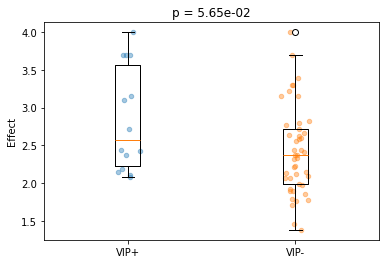

In [20]:

EFFECT = "p_beta_perm_Log"
data = [HumanCT_res_df_GeneL_VIP[EFFECT], HumanCT_res_df_GeneL_Other_IN[EFFECT]]

# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(
    HumanCT_res_df_GeneL_VIP[EFFECT], 
    HumanCT_res_df_GeneL_Other_IN[EFFECT]
)

# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])

# Add scatter points for each group
for i, d in enumerate(data):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)

plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()

### LGD vs Dmis

In [132]:
Mut_n_IQ_conf_LGD = Mut_n_IQ_conf[Mut_n_IQ_conf["GeneEff"]!="missense"]
Mut_n_IQ_conf_Dmis = Mut_n_IQ_conf[Mut_n_IQ_conf["GeneEff"]=="missense"]
print(Mut_n_IQ_conf.shape, Mut_n_IQ_conf_LGD.shape, Mut_n_IQ_conf_Dmis.shape)

(221, 11) (149, 11) (72, 11)


In [133]:
# Calculate gene level for Mut_n_IQ_conf
Genes_LGD = list(set(Mut_n_IQ_conf_LGD["Entrez"].values))
data_LGD = []
for g in Genes_LGD:
    tmp_df = Mut_n_IQ_conf_LGD[Mut_n_IQ_conf_LGD["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data_LGD.append(row)
columns = ["Entrez", "IQ"]
Avg_Gene_IQ_DF_LGD = pd.DataFrame(data=data_LGD, columns=columns)

# Calculate gene level for Mut_n_IQ_Dmis
Genes_Dmis = list(set(Mut_n_IQ_conf_Dmis["Entrez"].values))
data_Dmis = []
for g in Genes_Dmis:
    tmp_df = Mut_n_IQ_conf_Dmis[Mut_n_IQ_conf_Dmis["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data_Dmis.append(row)
Avg_Gene_IQ_DF_Dmis = pd.DataFrame(data=data_Dmis, columns=columns)



In [134]:
HumanCT_res_df_GeneL_LGD = Make_HumanCT_DF(Avg_Gene_IQ_DF_LGD, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.LGD.csv")
HumanCT_res_df_GeneL_Dmis = Make_HumanCT_DF(Avg_Gene_IQ_DF_Dmis, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.Dmis.csv")

/tmp/ipykernel_1084052/2720857543.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


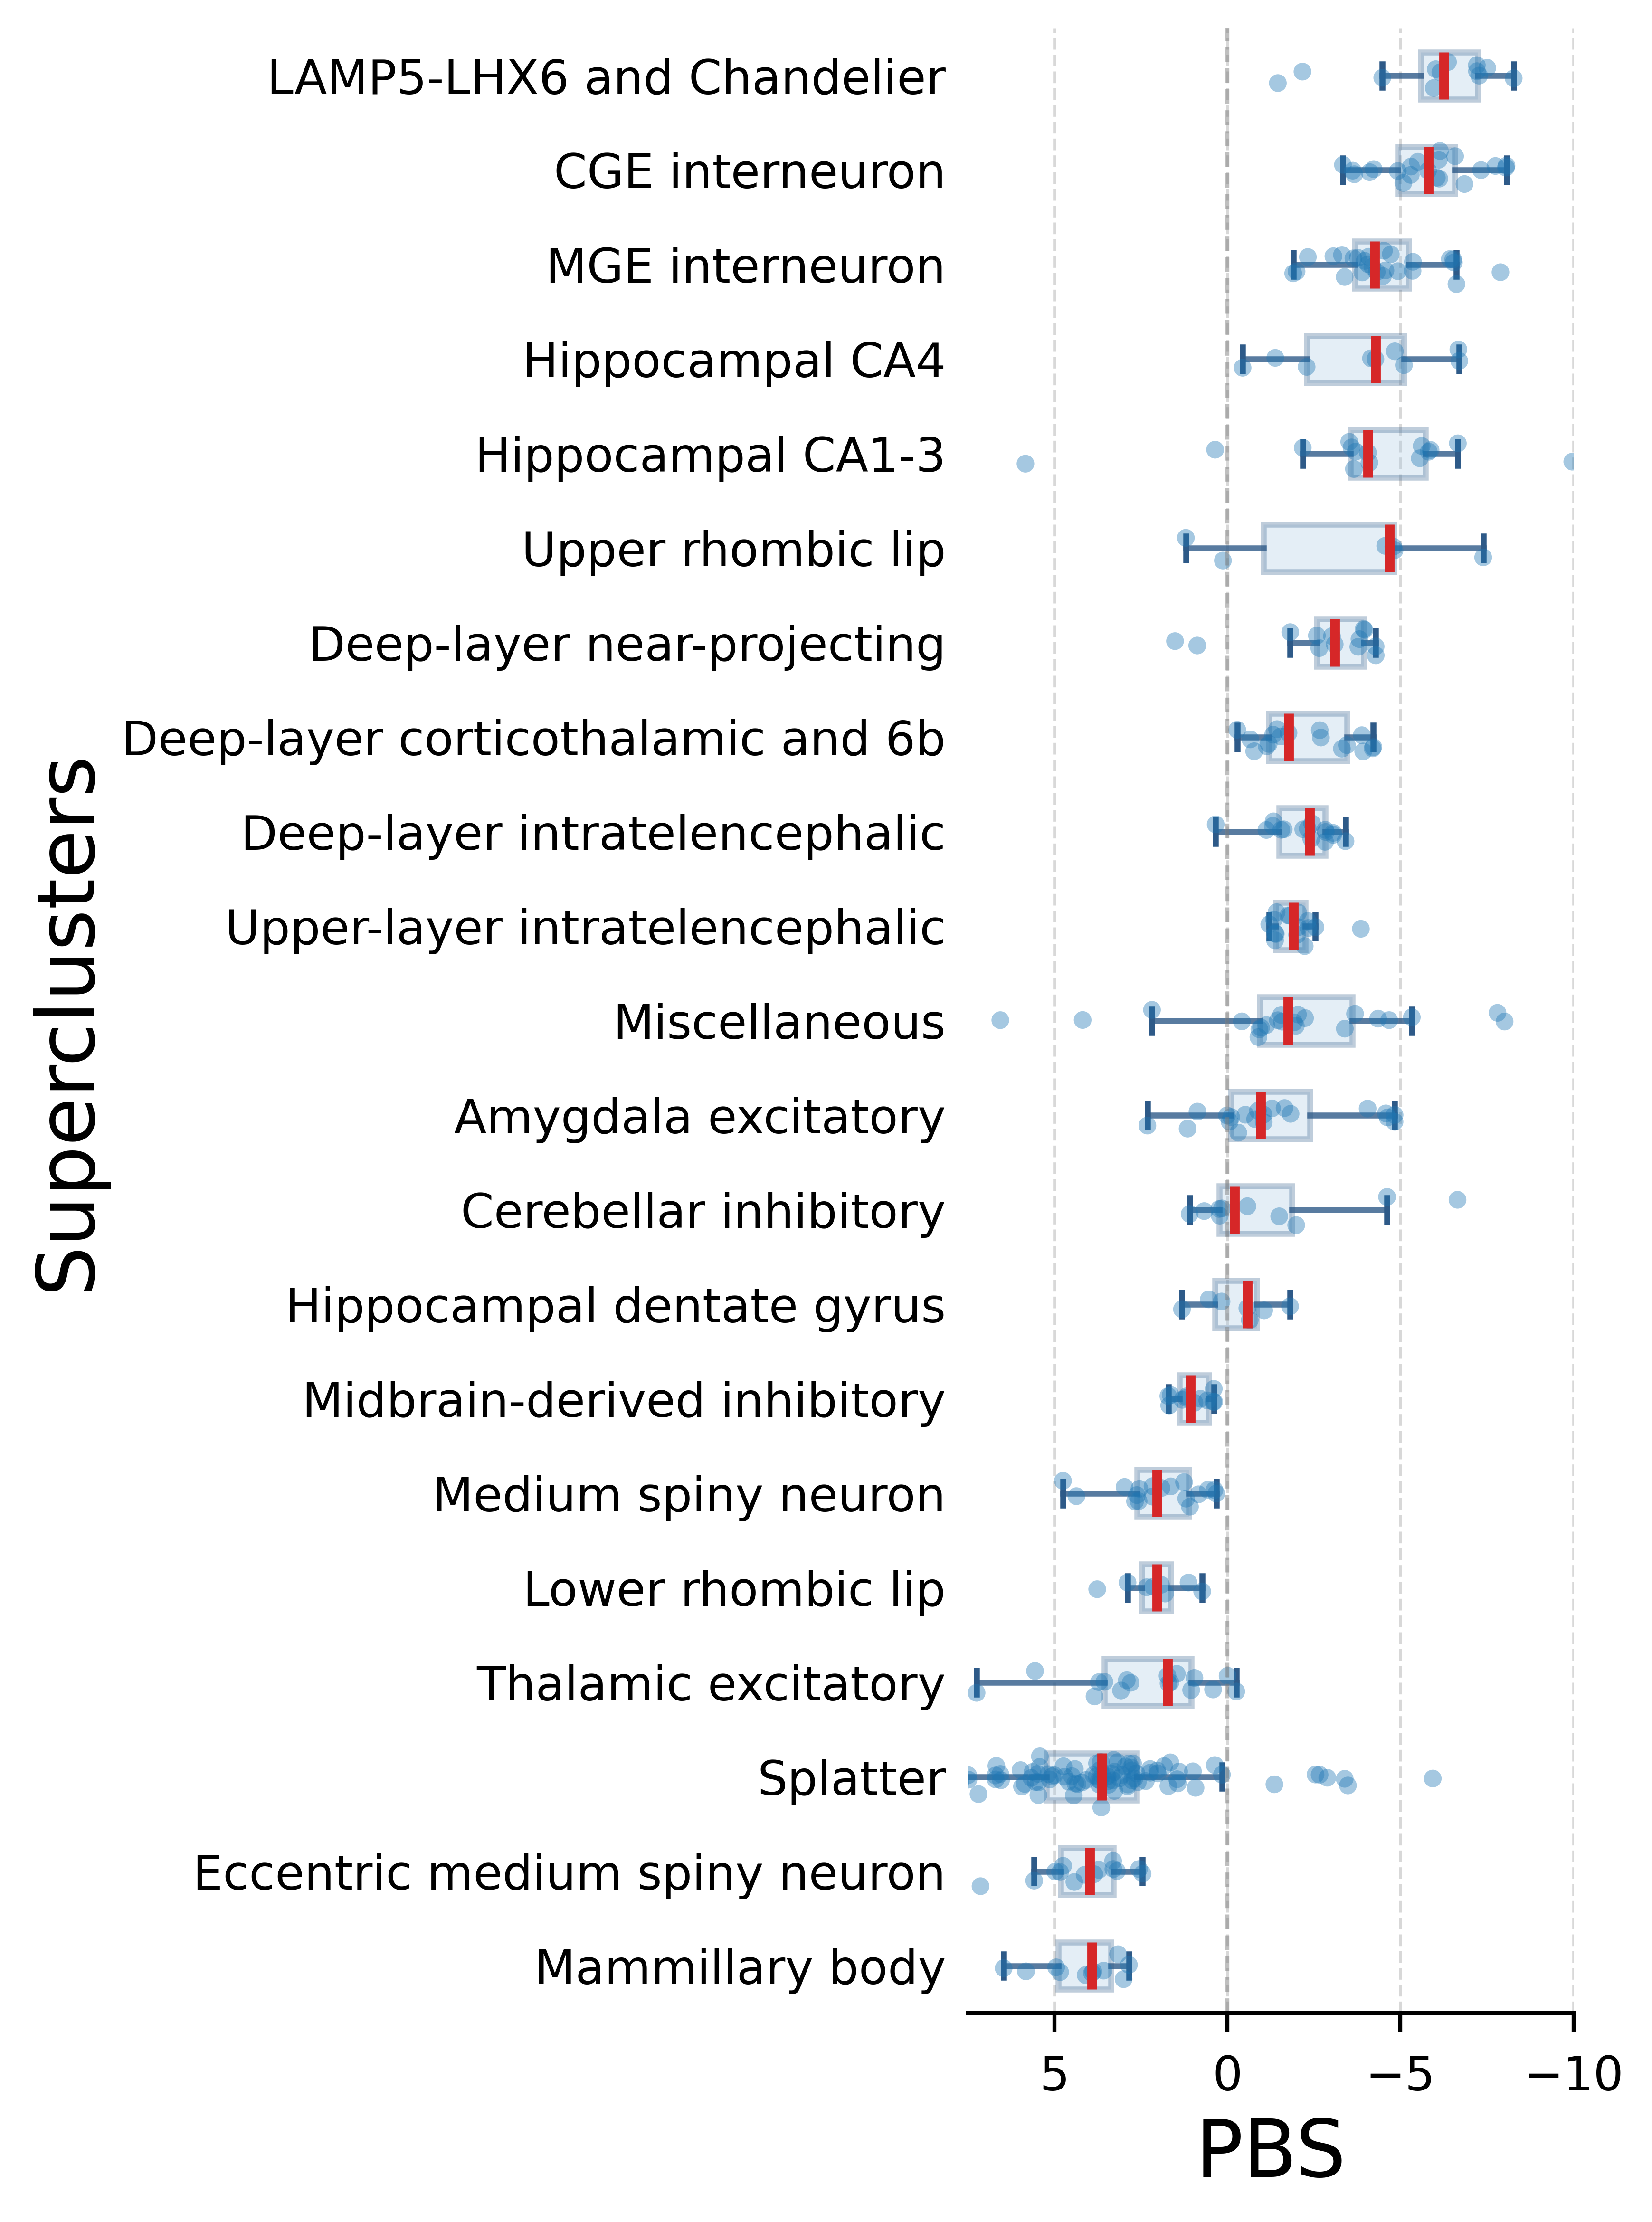

In [135]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL_LGD, flip_axis=True, figsize=(6, 8))

/tmp/ipykernel_1084052/2720857543.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


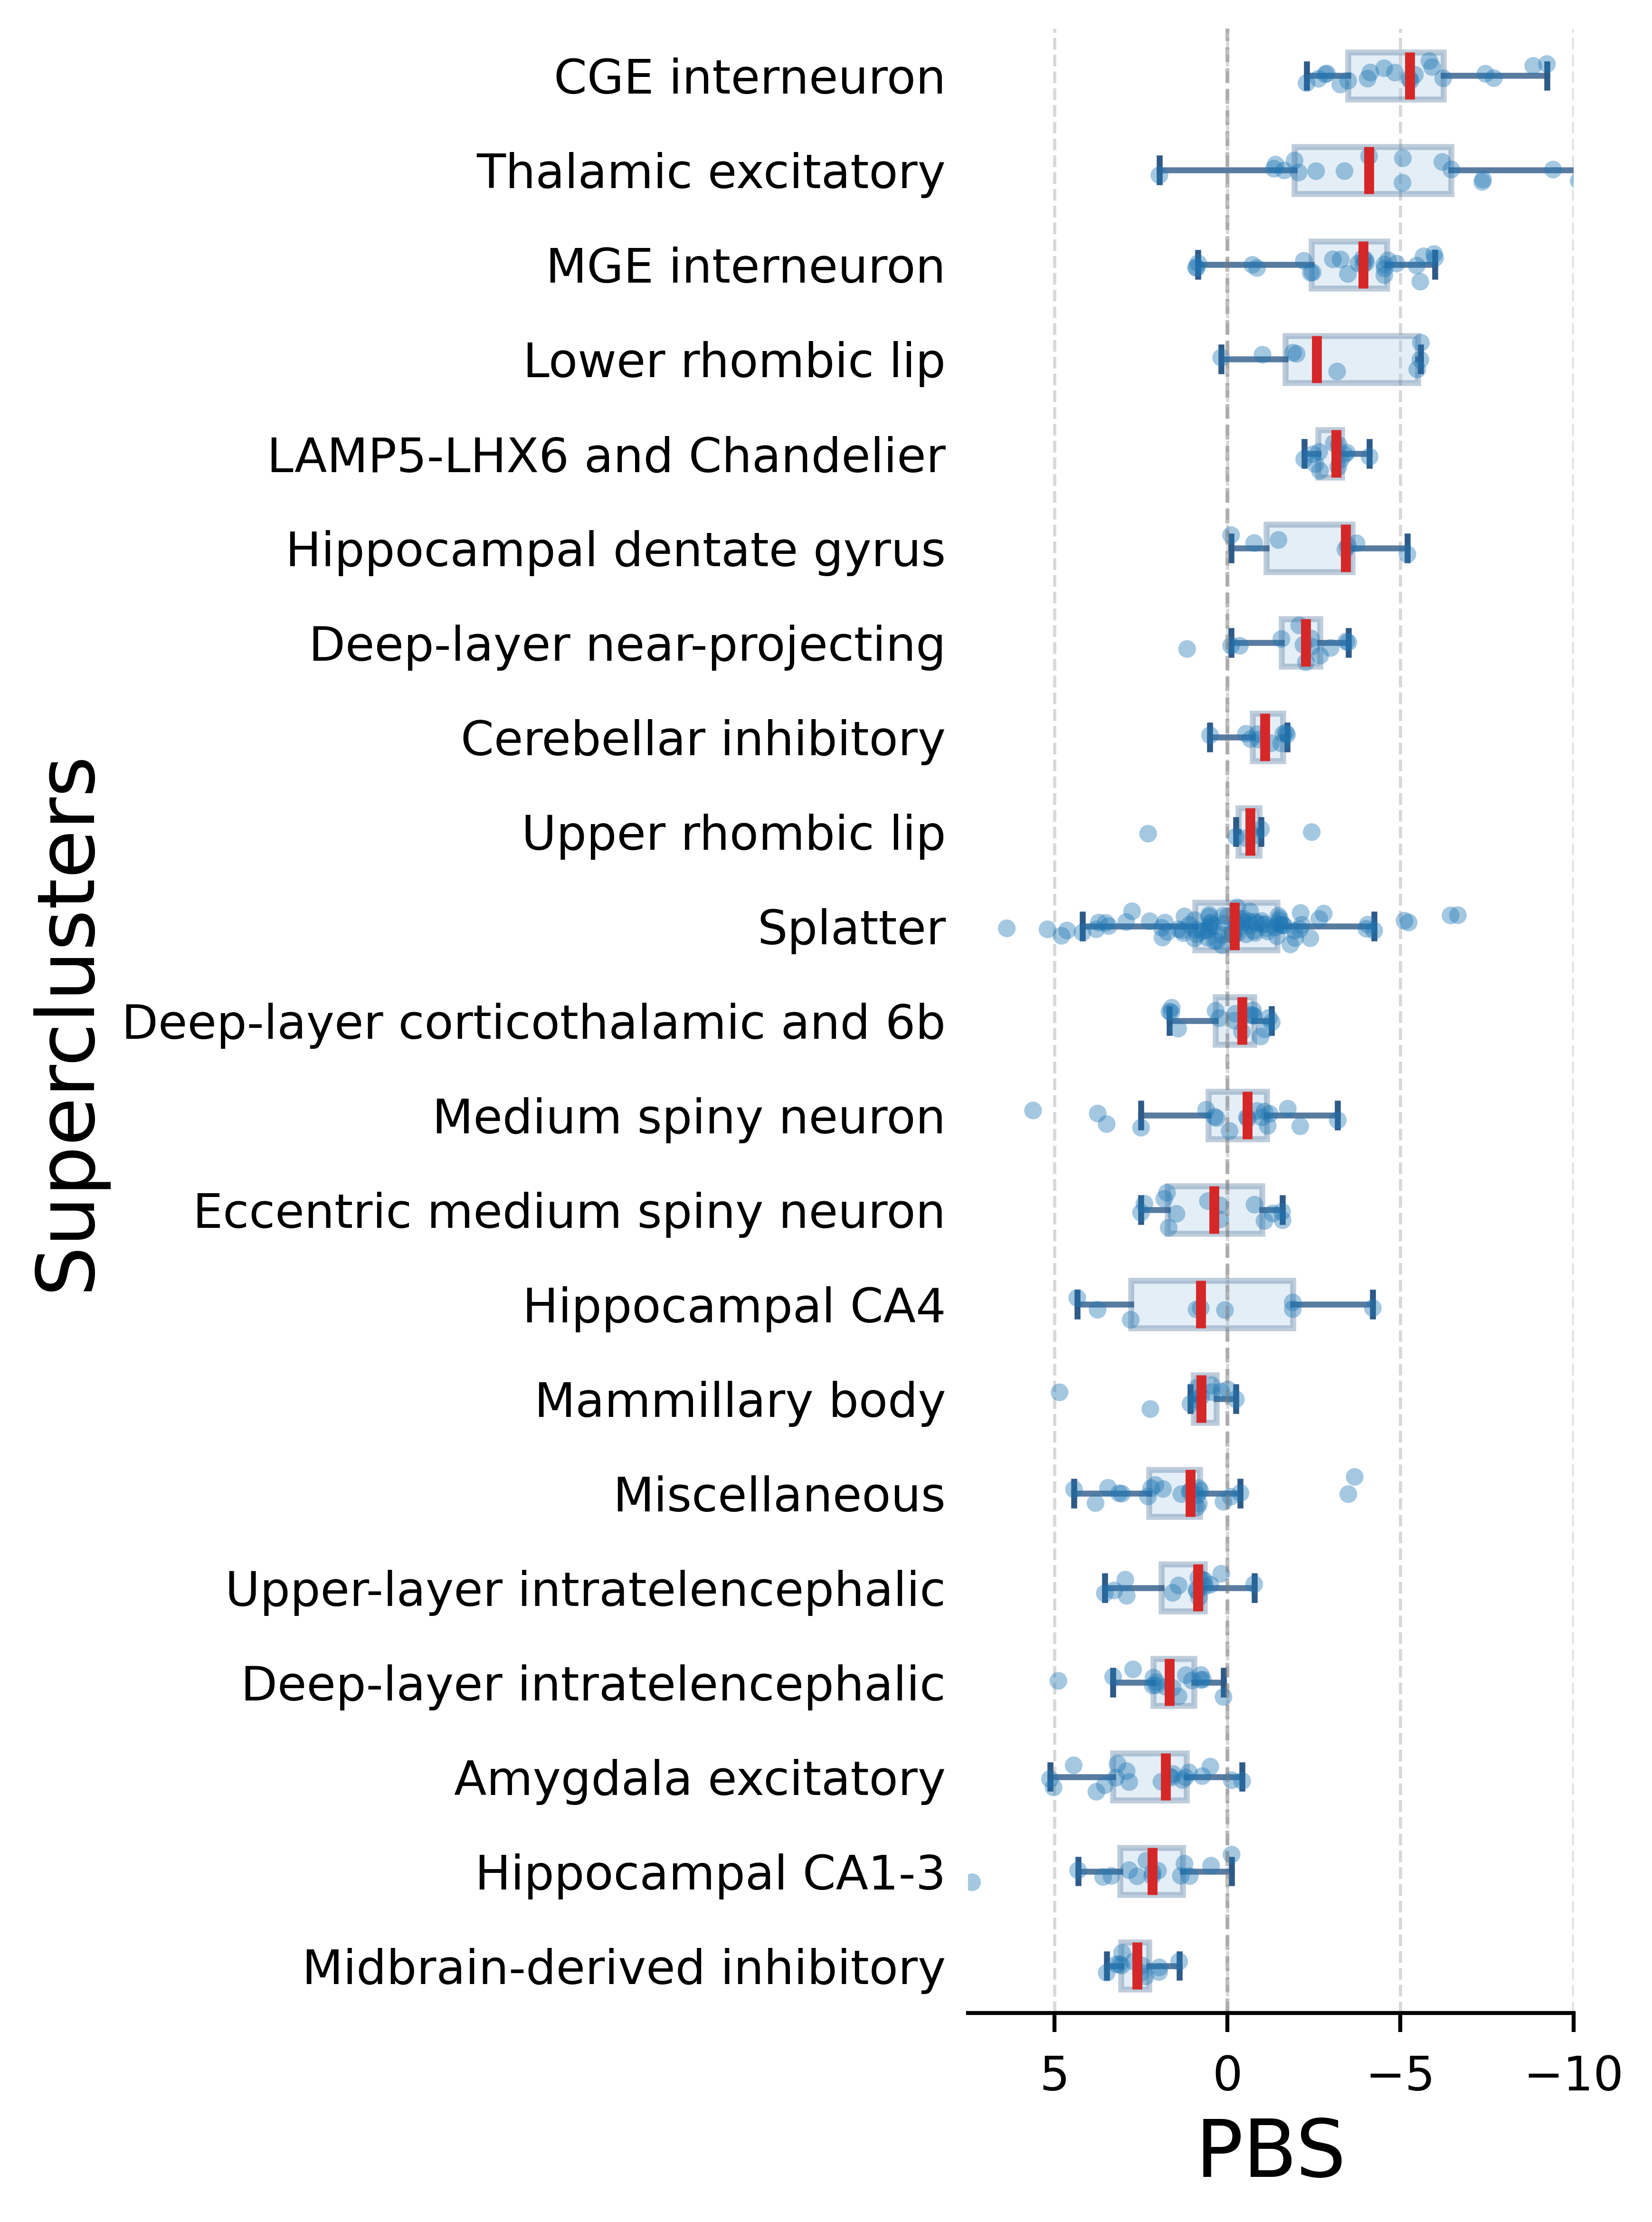

In [136]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL_Dmis, flip_axis=True, figsize=(6, 8))

In [137]:
Perm_DIR_LGD = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/LGD/"
Perm_DFs_LGD = []

max_count = 100000

i = 0
for df in os.listdir(Perm_DIR_LGD):
    df = pd.read_csv(f"{Perm_DIR_LGD}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs_LGD.append(df)
    i += 1
    if i > max_count:
        break
print(len(Perm_DFs_LGD))

Perm_DIR_Dmis = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/Dmis/"
Perm_DFs_Dmis = []

max_count = 100000

i = 0
for df in os.listdir(Perm_DIR_Dmis):
    df = pd.read_csv(f"{Perm_DIR_Dmis}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs_Dmis.append(df)
    i += 1
    if i > max_count:
        break
print(len(Perm_DFs_Dmis))

10000
10000


In [138]:
HumanCT_res_df_GeneL_LGD

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
266,266,LAMP5-LHX6 and Chandelier,-0.373283,0.006976,-0.309689,0.027003,-7.508829,-14.127316,-0.890341,62.375672,0.095907,0.027003,3.293476
276,276,CGE interneuron,-0.347399,0.012498,-0.279498,0.046998,-6.122169,-12.159847,-0.084490,65.341264,0.078119,0.046998,3.004455
277,277,CGE interneuron,-0.325723,0.019676,-0.285718,0.042110,-6.850552,-13.446873,-0.254231,64.944010,0.081635,0.042110,3.282446
267,267,LAMP5-LHX6 and Chandelier,-0.320927,0.021667,-0.338985,0.014960,-8.272923,-14.864336,-1.681510,63.678145,0.114911,0.014960,3.280003
237,237,Splatter,-0.298844,0.033154,-0.252998,0.073254,-5.933797,-12.447938,0.580344,64.140327,0.064008,0.073254,3.241551
...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,336,Splatter,0.285042,0.042620,0.441108,0.001196,6.546983,2.723013,10.370953,65.316415,0.194576,0.001196,1.902875
342,342,Splatter,0.291332,0.038063,0.309124,0.027298,5.545872,0.647708,10.444035,64.436290,0.095558,0.027298,2.437412
410,410,Splatter,0.301966,0.031275,0.391647,0.004482,8.318418,2.708013,13.928823,64.155217,0.153388,0.004482,2.791836
338,338,Splatter,0.316221,0.023782,0.335270,0.016172,5.070061,0.979983,9.160139,66.376095,0.112406,0.016172,2.035295


In [139]:
results_df_LGD = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho_LGD, p_beta_LGD = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL_LGD, Perm_DFs_LGD, plot=False)
    
    # Add results to DataFrame
    results_df_LGD = results_df_LGD.append({
        'Supercluster': Supercluster,
        'p_rho': p_rho_LGD,
        'p_beta': p_beta_LGD
    }, ignore_index=True)

/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future

In [140]:
results_df_Dmis = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho_Dmis, p_beta_Dmis = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL_Dmis, Perm_DFs_Dmis, plot=False)
    
    # Add results to DataFrame
    results_df_Dmis = results_df_Dmis.append({
        'Supercluster': Supercluster,
        'p_rho': p_rho_Dmis,
        'p_beta': p_beta_Dmis
    }, ignore_index=True)

/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in 

In [141]:
results_df_LGD

,Supercluster,p_rho,p_beta
0,Amygdala excitatory,0.3107,0.3024
1,CGE interneuron,0.0970,0.0530
2,Cerebellar inhibitory,0.3310,0.2581
3,Deep-layer corticothalamic and 6b,0.2331,0.2343
4,Deep-layer intratelencephalic,0.3710,0.1771
5,Deep-layer near-projecting,0.3955,0.2467
6,Eccentric medium spiny neuron,0.7394,0.8870
7,Hippocampal CA1-3,0.1521,0.0906
8,Hippocampal CA4,0.2419,0.1260
9,Hippocampal dentate gyrus,0.4402,0.4636


In [142]:
results_df_Dmis

,Supercluster,p_rho,p_beta
0,Amygdala excitatory,0.8564,0.8512
1,CGE interneuron,0.0318,0.0199
2,Cerebellar inhibitory,0.4912,0.2723
3,Deep-layer corticothalamic and 6b,0.1102,0.4904
4,Deep-layer intratelencephalic,0.4195,0.8465
5,Deep-layer near-projecting,0.2510,0.3208
6,Eccentric medium spiny neuron,0.5129,0.5461
7,Hippocampal CA1-3,0.9136,0.8122
8,Hippocampal CA4,0.5159,0.5528
9,Hippocampal dentate gyrus,0.1800,0.2472


# UKBB